In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.dates as mdates


from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import subprocess
import tempfile
import os

np.random.seed(8)

In [ ]:
# Please add path to interior/exterior file from Rich's email
exterior = pd.read_csv('data/pcr_from_R/exterior', sep=' ', header=None, names=['timestamp', 'exterior_value'])
interior = pd.read_csv('data/pcr_from_R/interior', sep=' ', header=None, names=['timestamp', 'interior_value'])

In [ ]:

# Convert Unix timestamps to datetime
# Reference: June 15, 2021 to Feb 24, 2023
exterior['datetime'] = pd.to_datetime(exterior['timestamp'], unit='s')
interior['datetime'] = pd.to_datetime(interior['timestamp'], unit='s')

# Convert windspeed from mph to m/s (1 mph = 0.44704 m/s)
MPH_TO_MS = 0.44704

# Negative values are most likely erroneous, make them 0
exterior['exterior_value'] = exterior['exterior_value'].clip(lower=0)
interior['interior_value'] = interior['interior_value'].clip(lower=0)

exterior['exterior_value_ms'] = exterior['exterior_value'] * MPH_TO_MS
interior['interior_value_ms'] = interior['interior_value'] * MPH_TO_MS

exterior = exterior.sort_values('timestamp')
interior = interior.sort_values('timestamp')
df = pd.merge_asof(exterior, interior, on='timestamp', direction='nearest', suffixes=('_ext', '_int'))

# Keep original mph values and add m/s converted values
df['exterior_value'] = df['exterior_value_ms']
df['interior_value'] = df['interior_value_ms']
df['datetime'] = df['datetime_ext']


print(f"Exterior shape: {exterior.shape}")
print(f"Interior shape: {interior.shape}")
print(f"Combined shape: {df.shape}")
print(f"\nDate range: {df['datetime'].min()} to {df['datetime'].max()}")
print(f"\nFirst few rows:")
print(df[['timestamp', 'datetime', 'exterior_value', 'interior_value']].head(10))
print(f"\nCheck for NaN values:")
print(df.isna().sum())

Exterior shape: (174113, 4)
Interior shape: (174095, 4)
Combined shape: (174113, 8)

Date range: 2021-06-15 13:21:06.727161884 to 2023-02-24 13:09:01.811999083

First few rows:
      timestamp                      datetime  exterior_value  interior_value
0  1.623763e+09 2021-06-15 13:21:06.727161884         2.68224         0.44704
1  1.623764e+09 2021-06-15 13:26:11.059176922         2.68224         0.44704
2  1.623764e+09 2021-06-15 13:31:15.341270924         2.23520         0.44704
3  1.623764e+09 2021-06-15 13:36:19.630161047         2.23520         0.44704
4  1.623764e+09 2021-06-15 13:41:23.901413918         2.68224         0.44704
5  1.623765e+09 2021-06-15 13:46:28.182797909         2.68224         0.44704
6  1.623765e+09 2021-06-15 13:51:32.536247969         3.12928         0.44704
7  1.623765e+09 2021-06-15 13:56:36.823508024         3.12928         0.44704
8  1.623766e+09 2021-06-15 14:01:41.015453100         3.12928         0.44704
9  1.623766e+09 2021-06-15 14:06:45.3061580

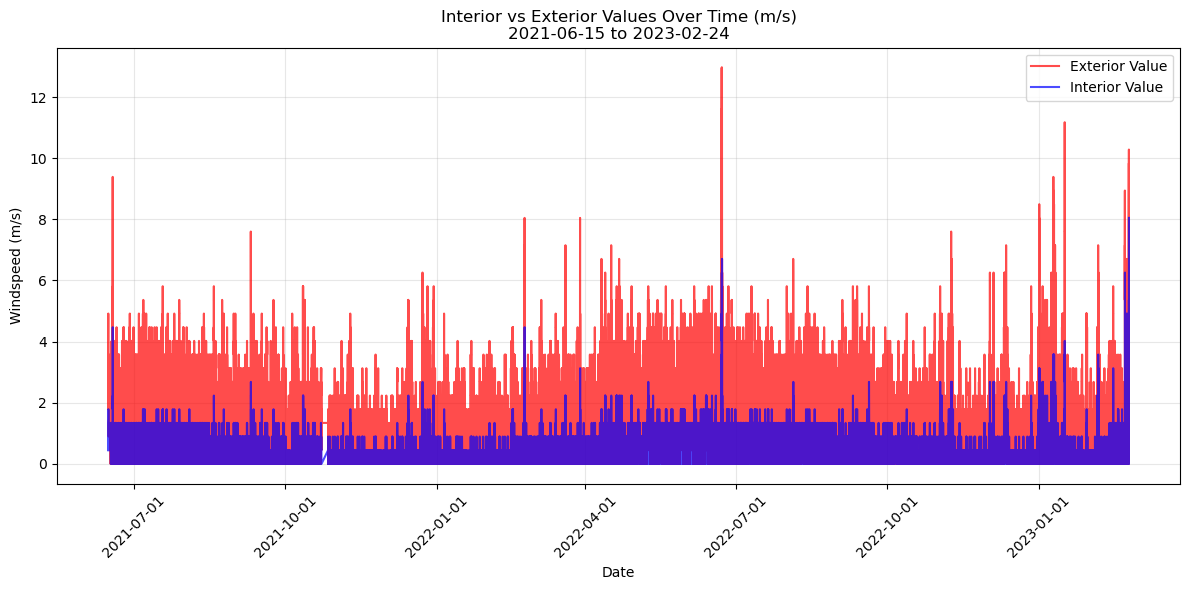

In [3]:
plt.figure(figsize=(12, 6))
plt.plot(df['datetime'], df['exterior_value'], c='red', label='Exterior Value', alpha=0.7)
plt.plot(df['datetime'], df['interior_value'], c='blue', label='Interior Value', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Windspeed (m/s)')
plt.title(f'Interior vs Exterior Values Over Time (m/s)\n{df["datetime"].min().strftime("%Y-%m-%d")} to {df["datetime"].max().strftime("%Y-%m-%d")}')
plt.legend()
# Format x-axis to show dates nicely
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

In [ ]:
# Edit path to PCR binary in the train_pcr_rich function below before running the notebook
def train_pcr_rich(X_values, Y_values, n_components=12):
    """
    Train PCR using Rich's binary.
    
    Args:
        X_values: List/array of input sequences (2D array: [n_samples, sequence_length])
        Y_values: List/array of target values (1D array: [n_samples])
        n_components: Number of PCA components (default: 12)
    
    Returns:
        Dictionary with 'coefficients', 'r_squared', 'rmse', or None if failed
    """

    pcr_binary = os.path.join(os.getcwd(), 'training2', 'pcr')
    with tempfile.NamedTemporaryFile(mode='w', suffix='.txt', delete=False) as x_file:
        x_path = x_file.name
        for seq in X_values:
            x_file.write(' '.join(f'{v:.6f}' for v in seq) + '\n')
    
    with tempfile.NamedTemporaryFile(mode='w', suffix='.txt', delete=False) as y_file:
        y_path = y_file.name
        for y_val in Y_values:
            y_file.write(f'{y_val:.6f}\n')
    
    try:
        cmd = [pcr_binary, '-x', x_path, '-y', y_path, '-c', str(n_components)]
        result = subprocess.run(cmd, capture_output=True, text=True, timeout=60)
        
        if result.returncode != 0:
            print(f"PCR binary failed: {result.stderr}")
            return None
        
        lines = result.stdout.strip().split('\n')
        
        coefficients = []
        r_squared = None
        rmse = None
        
        parsing_coefficients = False
        for line in lines:
            line = line.strip()
            
            if 'b: (PCR estimator)' in line:
                parsing_coefficients = True
                continue
            
            if parsing_coefficients:
                if line.startswith('R^2:'):
                    parsing_coefficients = False
                    parts = line.split()
                    for i, part in enumerate(parts):
                        if part == 'R^2:':
                            r_squared = float(parts[i + 1])
                        elif part == 'RMSE:':
                            rmse = float(parts[i + 1])
                else:
                    try:
                        coefficients.append(float(line))
                    except ValueError:
                        pass
        
        return {
            'coefficients': coefficients,
            'r_squared': r_squared,
            'rmse': rmse,
            'n_components': n_components
        }
    
    except subprocess.TimeoutExpired:
        print("PCR binary timed out")
        return None
    except Exception as e:
        print(f"Error running PCR binary: {e}")
        return None
    finally:
        # Clean up temporary files
        try:
            os.unlink(x_path)
            os.unlink(y_path)
        except:
            pass

print("train_pcr_rich function loaded!")


train_pcr_rich function loaded!


In [5]:


def train_pcr_python(X_values, Y_values, n_components=12):
    """
    Train PCR using Python/sklearn (your implementation).
    
    Args:
        X_values: List/array of input sequences (2D array: [n_samples, sequence_length])
        Y_values: List/array of target values (1D array: [n_samples])
        n_components: Number of PCA components (default: 12)
    
    Returns:
        Dictionary with 'coefficients', 'r_squared', 'rmse', and model components
    """
    X = np.array(X_values)
    y = np.array(Y_values)
    
    # Step 1: Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Step 2: PCA
    n_comp = min(n_components, X.shape[1])
    pca = PCA(n_components=n_comp)
    X_pca = pca.fit_transform(X_scaled)
    
    # Step 3: Linear Regression
    regressor = LinearRegression()
    regressor.fit(X_pca, y)
    
    # Calculate R^2 and RMSE
    y_pred = regressor.predict(X_pca)
    r_squared = regressor.score(X_pca, y)
    rmse = np.sqrt(np.mean((y - y_pred) ** 2))
    
    # For comparison with Rich's version, we need to compute the full coefficients
    # Rich's binary outputs: intercept + coefficients for original features
    # Our pipeline: X -> scale -> PCA -> regression
    
    # To get equivalent coefficients, we need to transform back:
    # y = intercept + sum(reg_coef[i] * PC[i])
    # PC[i] = sum(pca_comp[i,j] * (X[j] - scaler_mean[j]) / scaler_scale[j])
    
    # Combine transformations
    # Final coefficient for X[j] = sum_i(reg_coef[i] * pca_comp[i,j] / scaler_scale[j])
    feature_coefs = np.dot(regressor.coef_, pca.components_) / scaler.scale_
    
    # Adjust intercept
    intercept = regressor.intercept_ - np.dot(regressor.coef_, np.dot(pca.components_, scaler.mean_ / scaler.scale_))
    
    # Create coefficients list similar to Rich's output
    coefficients = [intercept] + feature_coefs.tolist()
    
    return {
        'coefficients': coefficients,
        'r_squared': r_squared,
        'rmse': rmse,
        'n_components': n_comp,
        'scaler': scaler,
        'pca': pca,
        'regressor': regressor
    }

print("train_pcr_python function loaded!")


train_pcr_python function loaded!


In [6]:
# Compare the two PCR implementations

# Prepare data: create sequences from exterior values, targets from interior values
sequence_length = 12
X_sequences = []
Y_targets = []

exterior_vals = df['exterior_value'].values
interior_vals = df['interior_value'].values

for i in range(len(exterior_vals) - sequence_length + 1):
    seq = exterior_vals[i:i + sequence_length]
    target = interior_vals[i + sequence_length - 1]
    X_sequences.append(seq)
    Y_targets.append(target)

X_sequences = np.array(X_sequences)
Y_targets = np.array(Y_targets)

print(f"Training data: {X_sequences.shape[0]} sequences of length {sequence_length}")
print(f"X shape: {X_sequences.shape}, Y shape: {Y_targets.shape}")

# Train using Rich's binary
print("\n=== Training with Rich's PCR binary ===")
result_rich = train_pcr_rich(X_sequences, Y_targets, n_components=12)
if result_rich:
    print(f"R²: {result_rich['r_squared']:.6f}")
    print(f"RMSE: {result_rich['rmse']:.6f}")
    print(f"Number of coefficients: {len(result_rich['coefficients'])}")
    print(f"First 5 coefficients: {result_rich['coefficients'][:5]}")

# Train using Python sklearn
print("\n=== Training with Python/sklearn PCR ===")
result_python = train_pcr_python(X_sequences, Y_targets, n_components=12)
print(f"R²: {result_python['r_squared']:.6f}")
print(f"RMSE: {result_python['rmse']:.6f}")
print(f"Number of coefficients: {len(result_python['coefficients'])}")
print(f"First 5 coefficients: {result_python['coefficients'][:5]}")

# Compare results
print("\n=== Comparison ===")
print(f"R² difference: {abs(result_rich['r_squared'] - result_python['r_squared']):.6f}")
print(f"RMSE difference: {abs(result_rich['rmse'] - result_python['rmse']):.6f}")

# Compare coefficients
if len(result_rich['coefficients']) == len(result_python['coefficients']):
    coef_diff = np.array(result_rich['coefficients']) - np.array(result_python['coefficients'])
    print(f"Max coefficient difference: {np.max(np.abs(coef_diff)):.6f}")
    print(f"Mean coefficient difference: {np.mean(np.abs(coef_diff)):.6f}")


Training data: 174102 sequences of length 12
X shape: (174102, 12), Y shape: (174102,)

=== Training with Rich's PCR binary ===
R²: 0.804341
RMSE: 0.197463
Number of coefficients: 13
First 5 coefficients: [-0.175444, 0.099321, 0.121242, 0.061628, 0.0024]

=== Training with Python/sklearn PCR ===
R²: 0.804341
RMSE: 0.197463
Number of coefficients: 13
First 5 coefficients: [np.float64(-0.17544377892569418), 0.09932062338201474, 0.12124232716829805, 0.06162826333607113, 0.00240039703554886]

=== Comparison ===
R² difference: 0.000000
RMSE difference: 0.000000
Max coefficient difference: 0.000000
Mean coefficient difference: 0.000000


In [8]:
def evaluate_pcr_on_random_periods(df, n_periods=10, train_window=72, test_window=72, 
                                   n_components=12, random_seed=42, 
                                   plot_periods=True, debug=False):
    """
    Evaluate PCR on randomly selected training/testing periods.
    
    Args:
        df: DataFrame with 'timestamp', 'datetime', 'exterior_value', 'interior_value'
        n_periods: Number of random periods to sample
        train_window: Length of training period (in samples)
        test_window: Length of testing period (in samples)
        n_components: Number of PCA components
        random_seed: Random seed for reproducibility
        plot_periods: Whether to plot each period
        debug: If True, print detailed progress information
    
    Returns:
        results_df: DataFrame with metrics for each period
    """
    
    results = []
    
    # Calculate maximum starting index (restrict to first 2/3 of data for training)
    max_start_for_train = int(len(df) * 2 / 3)
    max_valid_start = max_start_for_train - train_window
    
    if max_valid_start <= 0:
        print(f"Error: train_window ({train_window}) too large for available data")
        return None
    
    # Generate random starting indices
    np.random.seed(random_seed)
    random_starts = np.random.choice(max_valid_start, size=min(n_periods, max_valid_start), replace=False)
    
    if debug:
        print(f"Training PCR on {len(random_starts)} random periods...")
        print(f"Training window: {train_window} samples, Test window: {test_window} samples")
        print(f"Total data points: {len(df)}\n")
    
    for period_idx, start_idx in enumerate(random_starts):
        # Define train and test ranges
        train_start, train_end = start_idx, start_idx + train_window
        test_start = train_end
        test_end = min(test_start + test_window, len(df))
        
        # Skip if test period is too small
        if test_end - test_start < 10:
            if debug:
                print(f"Skipping period {period_idx + 1}: test period too small")
            continue
        
        # Extract data
        train_df = df.iloc[train_start:train_end]
        test_df = df.iloc[test_start:test_end]
        
        # Prepare features: exterior as X, interior as Y
        X_train = train_df['exterior_value'].values.reshape(-1, 1)
        y_train = train_df['interior_value'].values
        X_test = test_df['exterior_value'].values.reshape(-1, 1)
        y_test = test_df['interior_value'].values
        
        try:
            # Train PCR model
            model = train_pcr_python(X_train, y_train, n_components=min(n_components, X_train.shape[1]))
            
            # Make predictions on test set
            X_test_scaled = model['scaler'].transform(X_test)
            X_test_pca = model['pca'].transform(X_test_scaled)
            y_pred = model['regressor'].predict(X_test_pca)
            
            # Calculate test metrics
            test_rmse = np.sqrt(np.mean((y_test - y_pred)**2))
            test_mae = np.mean(np.abs(y_test - y_pred))
            
            # Get date ranges
            train_start_date = train_df['datetime'].iloc[0]
            train_end_date = train_df['datetime'].iloc[-1]
            test_start_date = test_df['datetime'].iloc[0]
            test_end_date = test_df['datetime'].iloc[-1]
            
            train_duration = train_end_date - train_start_date
            test_duration = test_end_date - test_start_date
            train_hours = train_duration.total_seconds() / 3600
            test_hours = test_duration.total_seconds() / 3600
            train_days = train_hours / 24
            test_days = test_hours / 24
            
            # Store results
            results.append({
                'period': period_idx + 1,
                'train_start': train_start,
                'train_end': train_end,
                'test_start': test_start,
                'test_end': test_end,
                'train_samples': train_end - train_start,
                'test_samples': test_end - test_start,
                'train_start_date': train_start_date,
                'train_end_date': train_end_date,
                'test_start_date': test_start_date,
                'test_end_date': test_end_date,
                'train_r2': model['r_squared'],
                'train_rmse': model['rmse'],
                'test_rmse': test_rmse,
                'test_mae': test_mae,
                'n_components': model['n_components']
            })
            
            if debug:
                print(f"Period {period_idx + 1}/{len(random_starts)} - "
                      f"Train: {train_start_date.strftime('%Y-%m-%d %H:%M')} to {train_end_date.strftime('%Y-%m-%d %H:%M')} ({train_hours:.1f} hours)")
                print(f"  Test: {test_start_date.strftime('%Y-%m-%d %H:%M')} to {test_end_date.strftime('%Y-%m-%d %H:%M')} ({test_hours:.1f} hours)")
                print(f"  Train R²: {model['r_squared']:.4f}, Train RMSE: {model['rmse']:.4f} m/s")
                print(f"  Test RMSE: {test_rmse:.4f} m/s, Test MAE: {test_mae:.4f} m/s\n")
            
            # Plot if requested
            if plot_periods:
                fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
                
                # Determine time display format
                use_hours_train = train_days < 2
                use_hours_test = test_days < 2
                
                # Plot training period
                if use_hours_train:
                    train_time_start = train_df['datetime'].iloc[0]
                    train_hours_elapsed = [(dt - train_time_start).total_seconds() / 3600 for dt in train_df['datetime']]
                    ax1.plot(train_hours_elapsed, train_df['exterior_value'].values, 'r-', label='Exterior', alpha=0.7)
                    ax1.plot(train_hours_elapsed, train_df['interior_value'].values, 'b-', label='Interior', alpha=0.7)
                    ax1.set_xlabel('Time (hours)')
                    ax1.set_title(f'Period {period_idx + 1} - Training Data ({train_hours:.1f} hours)\n{train_start_date.strftime("%Y-%m-%d %H:%M")}')
                else:
                    ax1.plot(train_df['datetime'].values, train_df['exterior_value'].values, 'r-', label='Exterior', alpha=0.7)
                    ax1.plot(train_df['datetime'].values, train_df['interior_value'].values, 'b-', label='Interior', alpha=0.7)
                    ax1.set_xlabel('Date')
                    ax1.set_title(f'Period {period_idx + 1} - Training Data ({train_days:.1f} days)\n{train_start_date.strftime("%Y-%m-%d")} to {train_end_date.strftime("%Y-%m-%d")}')
                    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
                    ax1.tick_params(axis='x', rotation=45)
                
                ax1.set_ylabel('Windspeed (m/s)')
                ax1.legend()
                ax1.grid(True, alpha=0.3)
                
                # Plot testing period with predictions
                if use_hours_test:
                    test_time_start = test_df['datetime'].iloc[0]
                    test_hours_elapsed = [(dt - test_time_start).total_seconds() / 3600 for dt in test_df['datetime']]
                    ax2.plot(test_hours_elapsed, test_df['exterior_value'].values, 'r-', label='Exterior', alpha=0.7)
                    ax2.plot(test_hours_elapsed, y_test, 'b-', label='Interior (actual)', alpha=0.7)
                    ax2.plot(test_hours_elapsed, y_pred, 'g--', label='Interior (predicted)', alpha=0.7, linewidth=2)
                    ax2.set_xlabel('Time (hours)')
                    ax2.set_title(f'Period {period_idx + 1} - Testing Data & Predictions ({test_hours:.1f} hours)\n{test_start_date.strftime("%Y-%m-%d %H:%M")}')
                else:
                    ax2.plot(test_df['datetime'].values, test_df['exterior_value'].values, 'r-', label='Exterior', alpha=0.7)
                    ax2.plot(test_df['datetime'].values, y_test, 'b-', label='Interior (actual)', alpha=0.7)
                    ax2.plot(test_df['datetime'].values, y_pred, 'g--', label='Interior (predicted)', alpha=0.7, linewidth=2)
                    ax2.set_xlabel('Date')
                    ax2.set_title(f'Period {period_idx + 1} - Testing Data & Predictions ({test_days:.1f} days)\n{test_start_date.strftime("%Y-%m-%d")} to {test_end_date.strftime("%Y-%m-%d")}')
                    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
                    ax2.tick_params(axis='x', rotation=45)
                
                ax2.set_ylabel('Windspeed (m/s)')
                ax2.legend()
                ax2.grid(True, alpha=0.3)
                
                plt.tight_layout()
                plt.show()
            
        except Exception as e:
            print(f"Error in period {period_idx + 1}: {e}\n")
    
    # Create results DataFrame and print summary
    if results:
        results_df = pd.DataFrame(results)
        
        print("\n" + "="*70)
        print("SUMMARY STATISTICS")
        print("="*70)
        print(f"\nTraining Performance:")
        print(f"  Mean R²: {results_df['train_r2'].mean():.4f} ± {results_df['train_r2'].std():.4f}")
        print(f"  Mean RMSE: {results_df['train_rmse'].mean():.4f} ± {results_df['train_rmse'].std():.4f} m/s")
        print(f"\nTesting Performance:")
        print(f"  Mean RMSE: {results_df['test_rmse'].mean():.4f} ± {results_df['test_rmse'].std():.4f} m/s")
        print(f"  Mean MAE: {results_df['test_mae'].mean():.4f} ± {results_df['test_mae'].std():.4f} m/s")
        
        if debug:
            print("\n" + "="*70)
            print("DETAILED RESULTS")
            print("="*70)
            print(results_df.to_string(index=False))
        
        return results_df
    
    return None

print("evaluate_pcr_on_random_periods function loaded!")

evaluate_pcr_on_random_periods function loaded!


Training PCR on 10 random periods...
Training window: 72 samples, Test window: 72 samples
Total data points: 174113

Period 1/10 - Train: 2022-04-03 06:09 to 2022-04-03 12:09 (6.0 hours)
  Test: 2022-04-03 12:14 to 2022-04-03 18:14 (6.0 hours)
  Train R²: 1.0000, Train RMSE: 0.0000 m/s
  Test RMSE: 0.4470 m/s, Test MAE: 0.2359 m/s



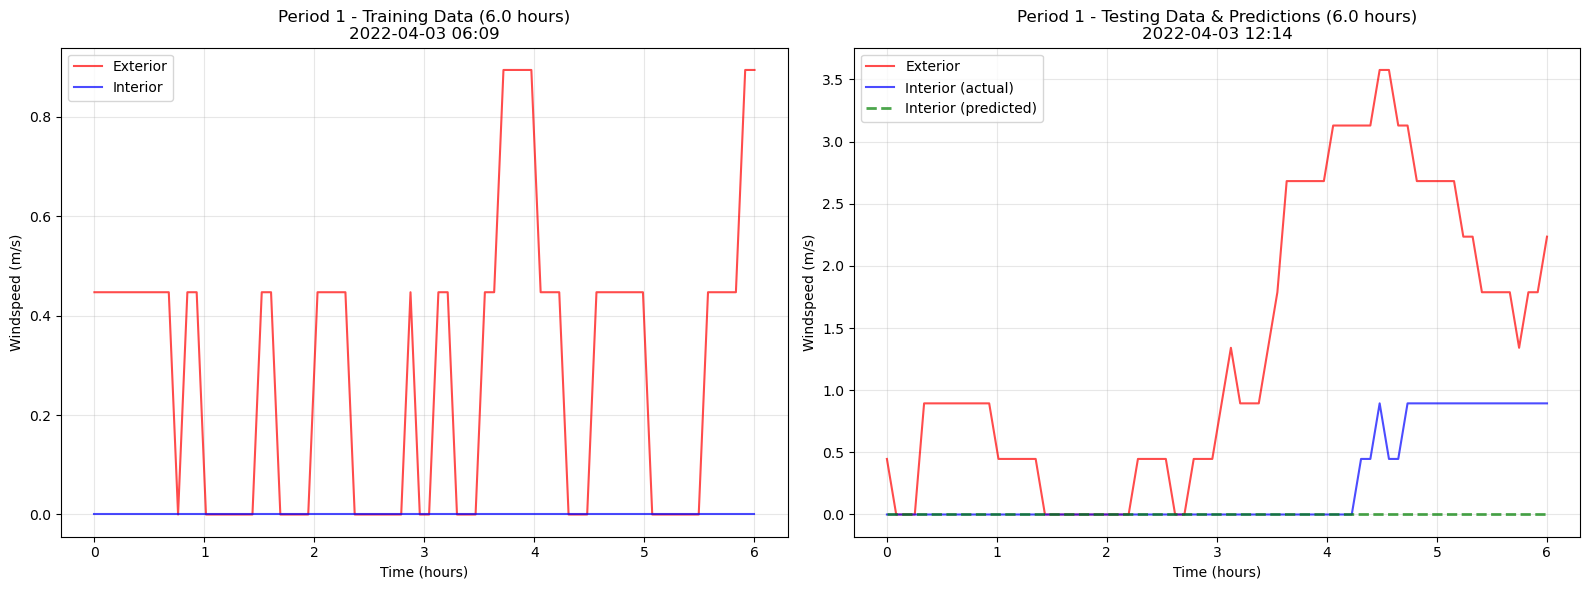

Period 2/10 - Train: 2022-07-05 04:39 to 2022-07-05 10:39 (6.0 hours)
  Test: 2022-07-05 10:44 to 2022-07-05 16:44 (6.0 hours)
  Train R²: 1.0000, Train RMSE: 0.0000 m/s
  Test RMSE: 0.5026 m/s, Test MAE: 0.2546 m/s



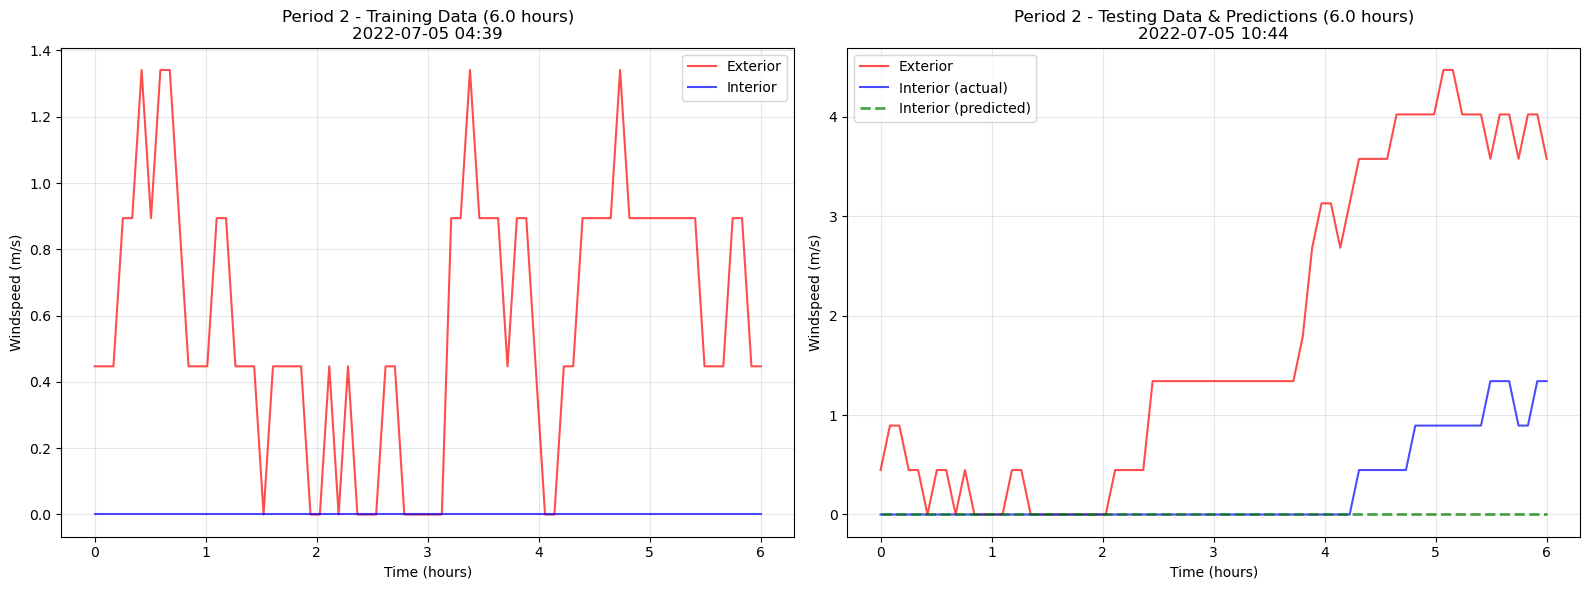

Period 3/10 - Train: 2022-02-13 14:48 to 2022-02-13 20:48 (6.0 hours)
  Test: 2022-02-13 20:53 to 2022-02-14 02:53 (6.0 hours)
  Train R²: 0.0200, Train RMSE: 0.0884 m/s
  Test RMSE: 0.1881 m/s, Test MAE: 0.1041 m/s



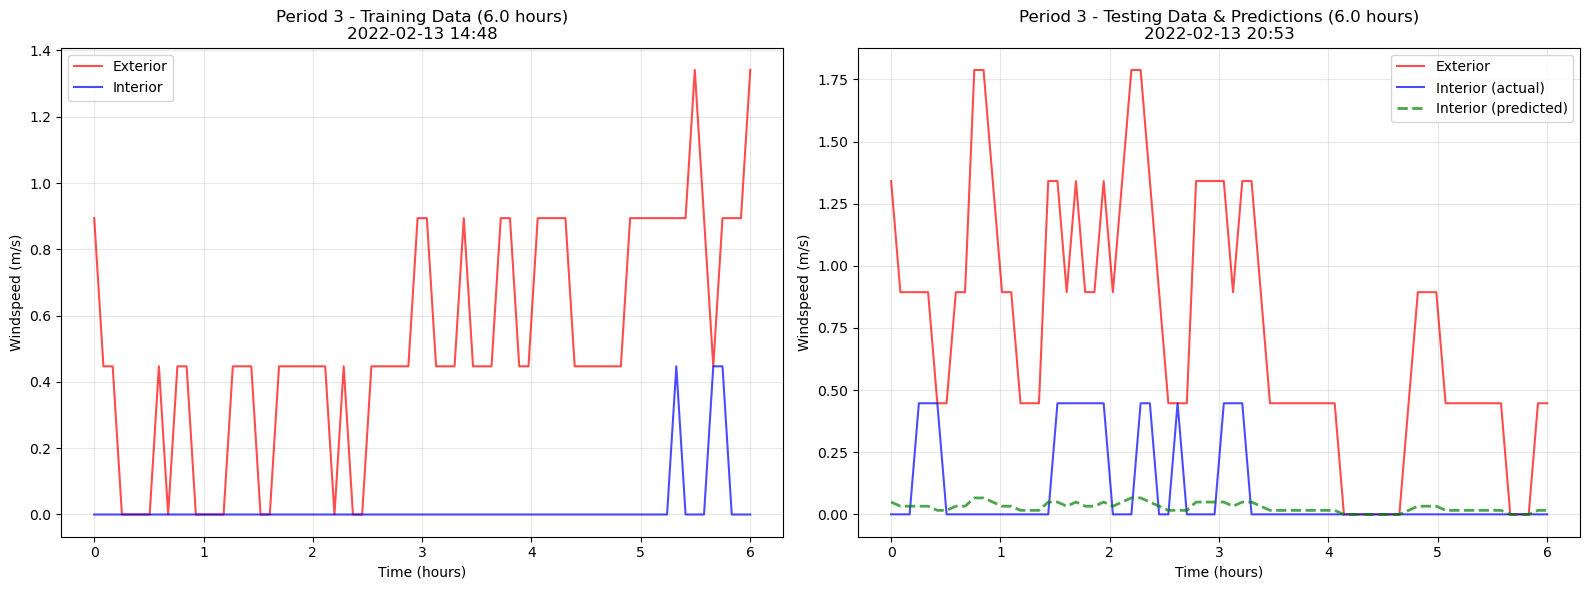

Period 4/10 - Train: 2021-09-20 19:45 to 2021-09-21 01:45 (6.0 hours)
  Test: 2021-09-21 01:50 to 2021-09-21 07:50 (6.0 hours)
  Train R²: 0.3303, Train RMSE: 0.1811 m/s
  Test RMSE: 0.1091 m/s, Test MAE: 0.0883 m/s



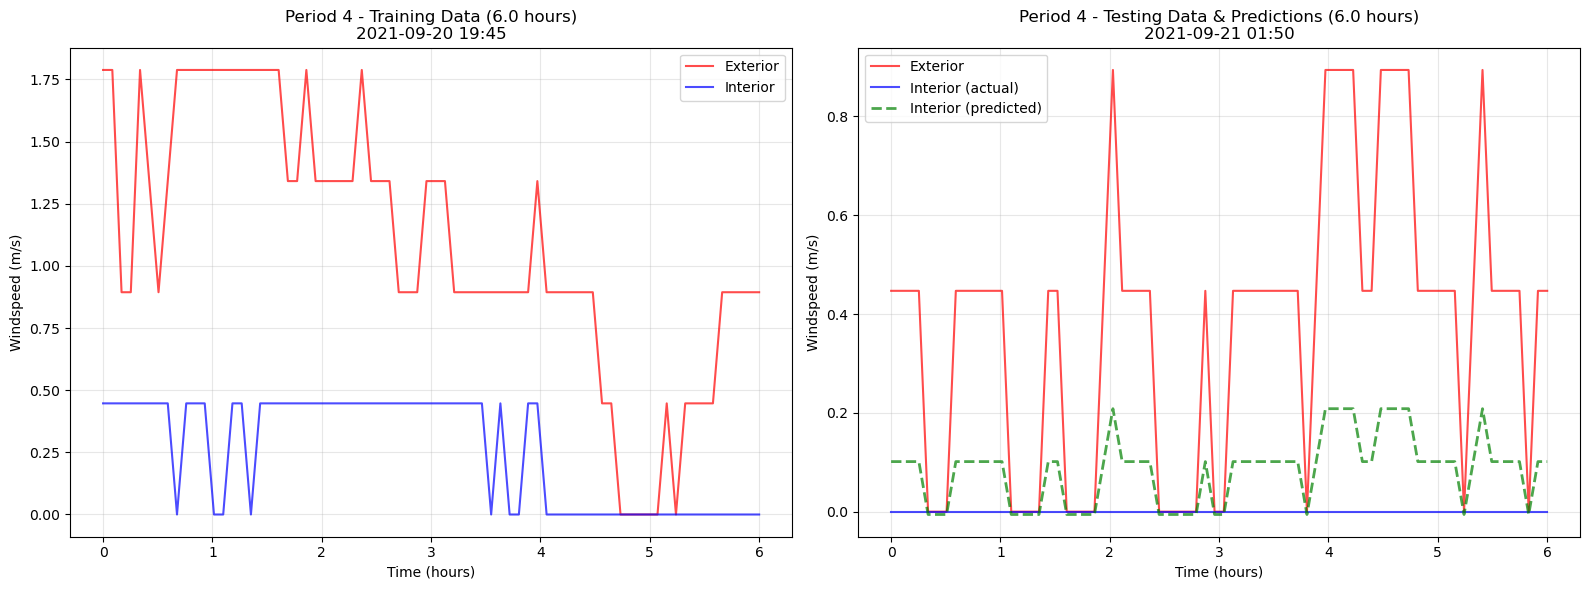

Period 5/10 - Train: 2022-05-09 03:41 to 2022-05-09 09:41 (6.0 hours)
  Test: 2022-05-09 09:46 to 2022-05-09 15:46 (6.0 hours)
  Train R²: 0.0339, Train RMSE: 0.3512 m/s
  Test RMSE: 0.9528 m/s, Test MAE: 0.9224 m/s



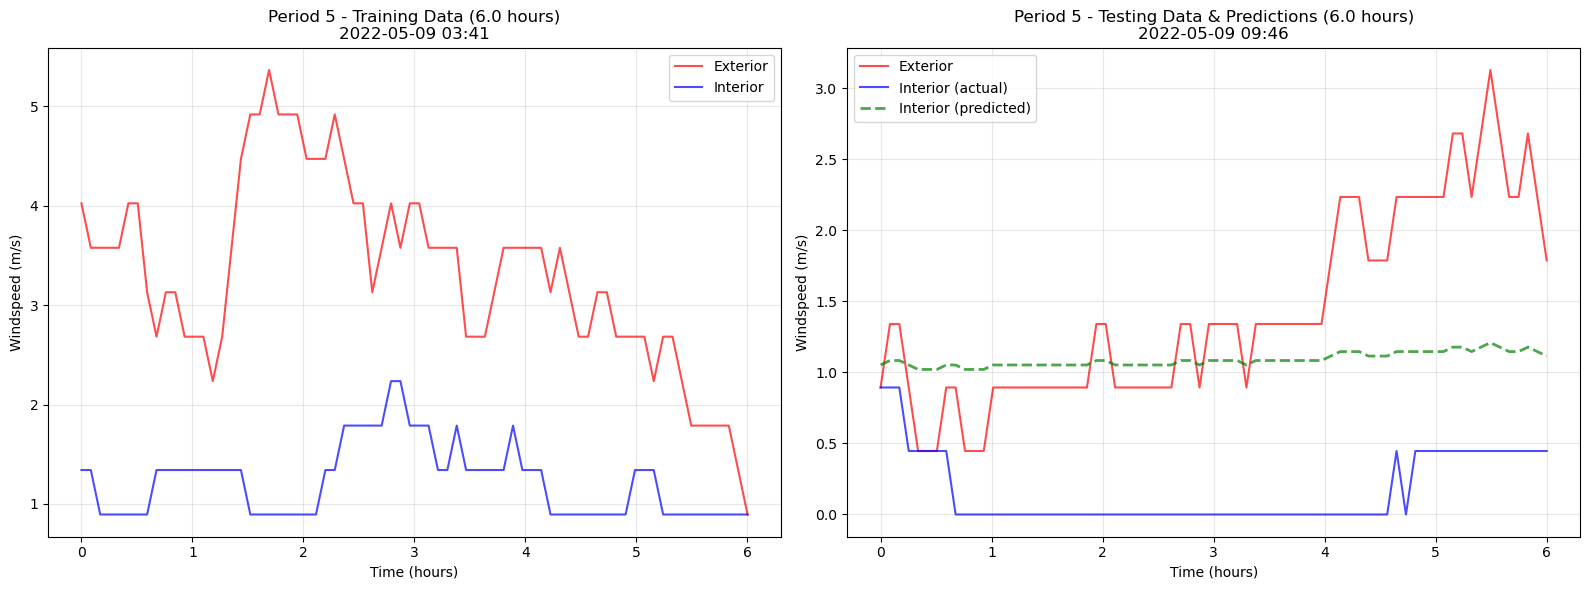

Period 6/10 - Train: 2022-07-23 15:32 to 2022-07-23 21:32 (6.0 hours)
  Test: 2022-07-23 21:37 to 2022-07-24 03:37 (6.0 hours)
  Train R²: 0.0272, Train RMSE: 0.2939 m/s
  Test RMSE: 0.5138 m/s, Test MAE: 0.4365 m/s



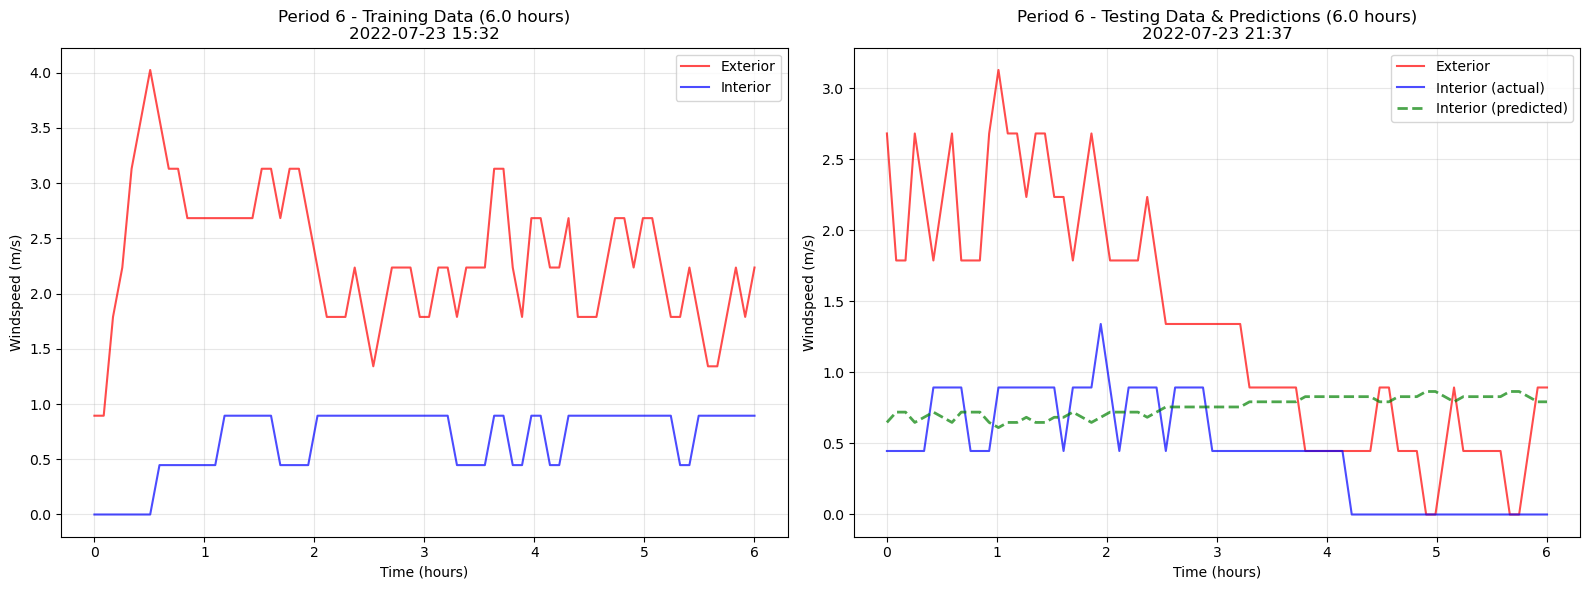

Period 7/10 - Train: 2021-12-11 08:44 to 2021-12-11 14:44 (6.0 hours)
  Test: 2021-12-11 14:50 to 2021-12-11 20:50 (6.0 hours)
  Train R²: 1.0000, Train RMSE: 0.0000 m/s
  Test RMSE: 0.0745 m/s, Test MAE: 0.0124 m/s



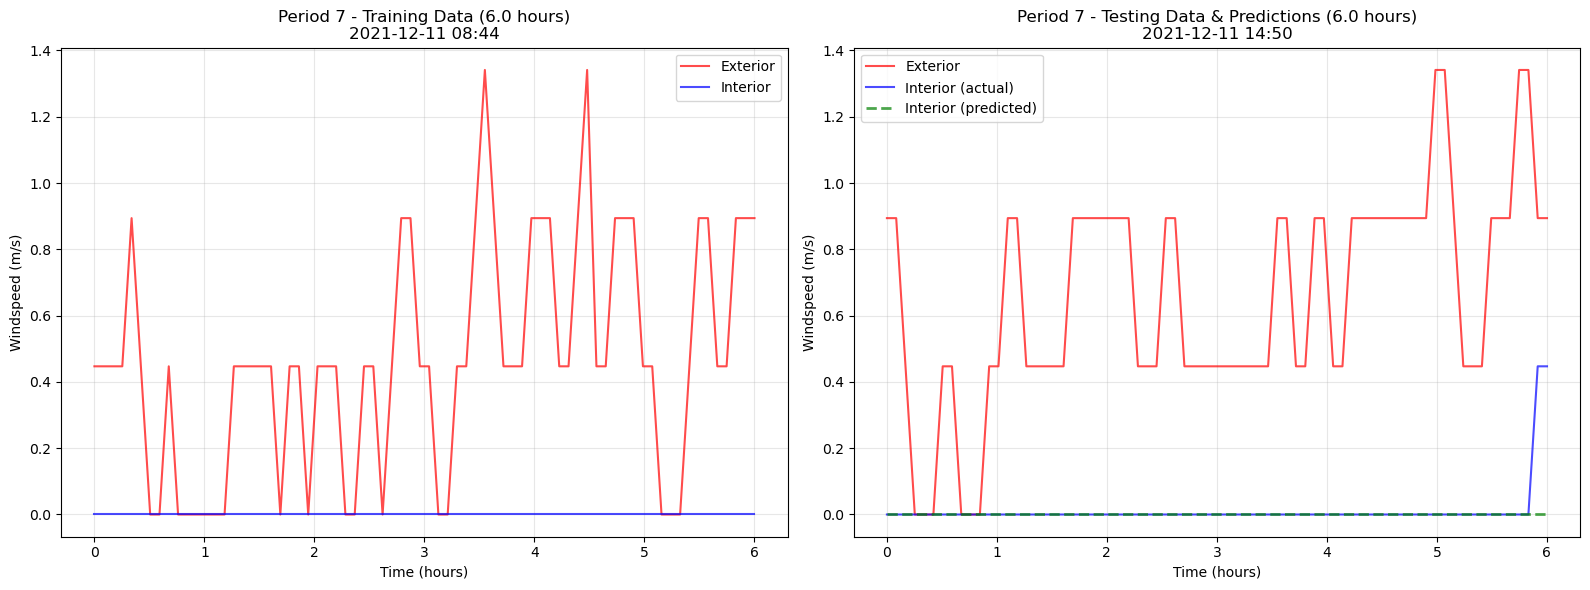

Period 8/10 - Train: 2021-11-17 17:31 to 2021-11-17 23:31 (6.0 hours)
  Test: 2021-11-17 23:36 to 2021-11-18 05:36 (6.0 hours)
  Train R²: 0.0142, Train RMSE: 0.2319 m/s
  Test RMSE: 0.2261 m/s, Test MAE: 0.2243 m/s



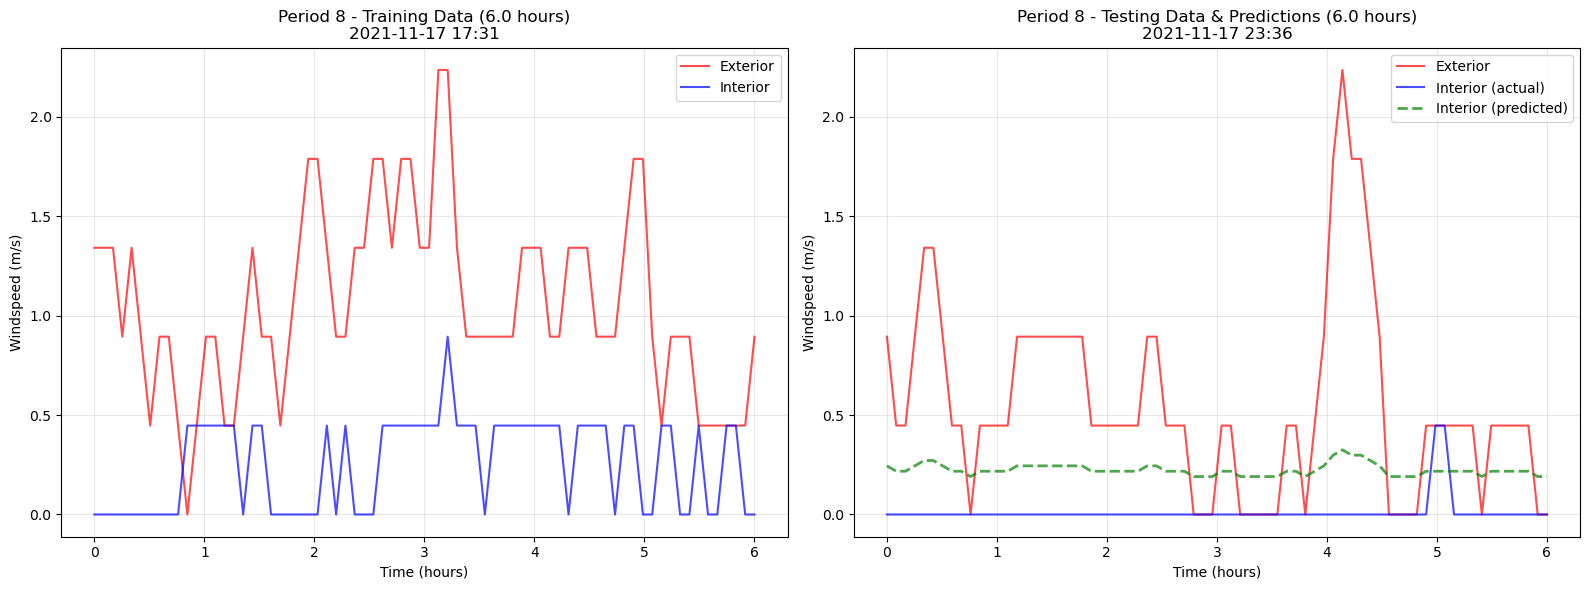

Period 9/10 - Train: 2022-07-09 01:17 to 2022-07-09 07:17 (6.0 hours)
  Test: 2022-07-09 07:23 to 2022-07-09 13:23 (6.0 hours)
  Train R²: 0.2905, Train RMSE: 0.2998 m/s
  Test RMSE: 0.3846 m/s, Test MAE: 0.3545 m/s



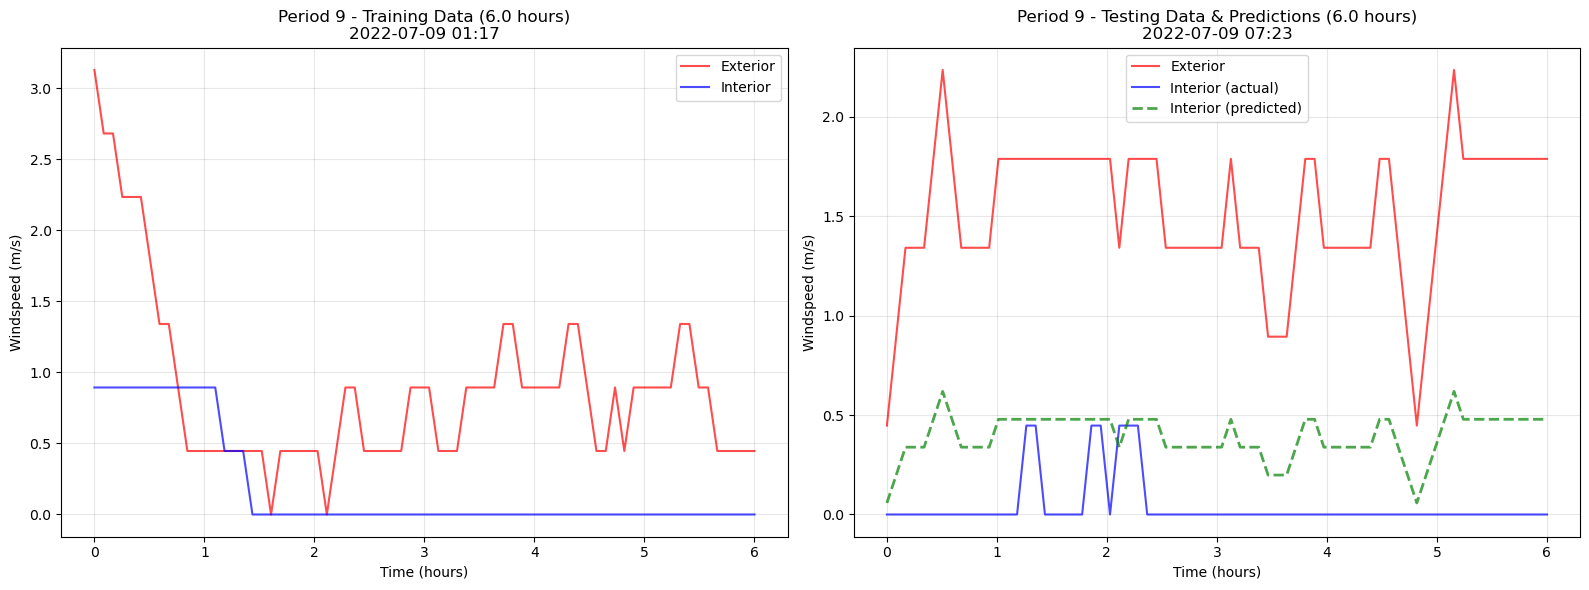

Period 10/10 - Train: 2021-08-03 10:05 to 2021-08-03 16:05 (6.0 hours)
  Test: 2021-08-03 16:10 to 2021-08-03 22:10 (6.0 hours)
  Train R²: 0.0406, Train RMSE: 0.0720 m/s
  Test RMSE: 0.9586 m/s, Test MAE: 0.8905 m/s



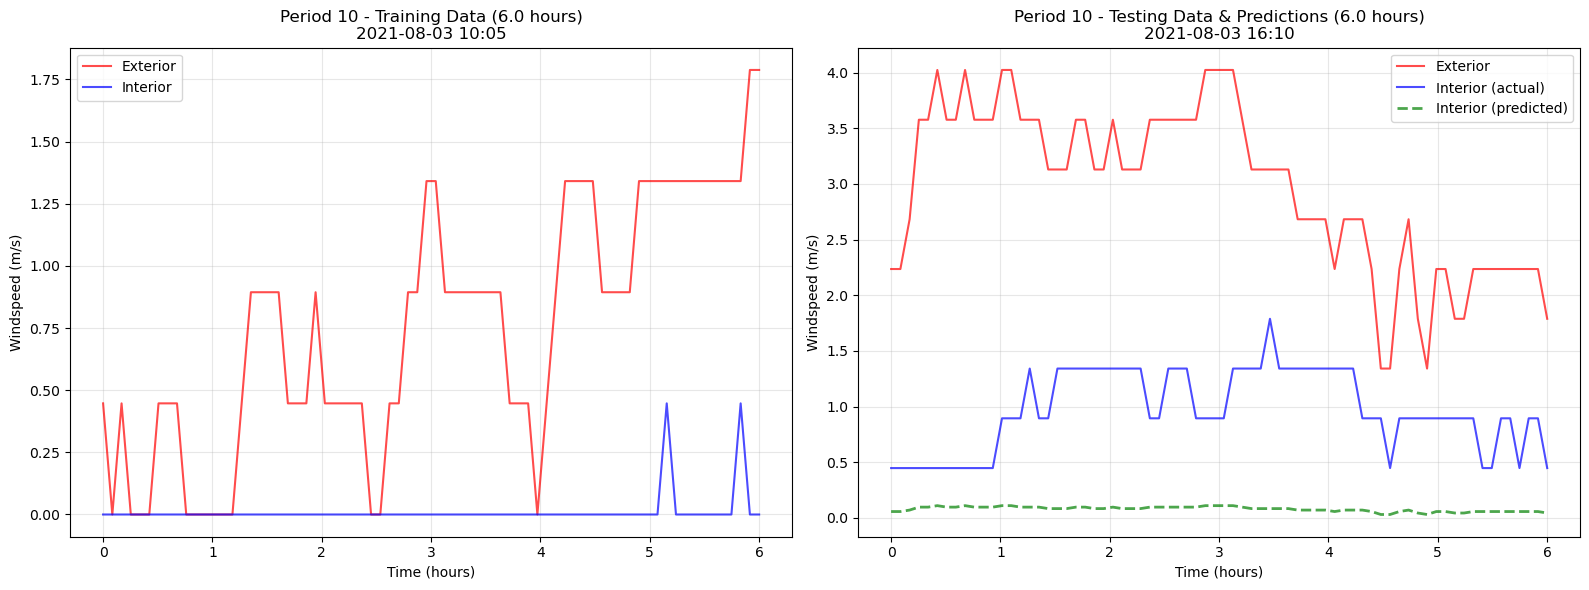


SUMMARY STATISTICS

Training Performance:
  Mean R²: 0.3757 ± 0.4455
  Mean RMSE: 0.1518 ± 0.1369 m/s

Testing Performance:
  Mean RMSE: 0.4357 ± 0.3156 m/s
  Mean MAE: 0.3523 ± 0.3176 m/s

DETAILED RESULTS
 period  train_start  train_end  test_start  test_end  train_samples  test_samples              train_start_date                train_end_date               test_start_date                 test_end_date  train_r2  train_rmse  test_rmse  test_mae  n_components
      1        81410      81482       81482     81554             72            72 2022-04-03 06:09:04.528662920 2022-04-03 12:09:08.532567978 2022-04-03 12:14:12.820811033 2022-04-03 18:14:16.045545101  1.000000    0.000000   0.447040  0.235938             1
      2       107777     107849      107849    107921             72            72 2022-07-05 04:39:47.218837976 2022-07-05 10:39:49.483455896 2022-07-05 10:44:53.665386915 2022-07-05 16:44:57.541567087  1.000000    0.000000   0.502575  0.254564             1
      3     

In [9]:
# Evaluate PCR on random periods with train_window=72, test_window=72
results_df = evaluate_pcr_on_random_periods(
    df, 
    n_periods=10, 
    train_window=72, 
    test_window=72, 
    n_components=12,
    random_seed=42,
    plot_periods=True,
    debug=True
)

Training PCR on 10 random periods...
Training window: 720 samples, Test window: 720 samples
Total data points: 174113

Period 1/10 - Train: 2022-04-30 04:29 to 2022-05-02 17:15 (60.8 hours)
  Test: 2022-05-02 17:20 to 2022-05-05 06:07 (60.8 hours)
  Train R²: 0.6090, Train RMSE: 0.2500 m/s
  Test RMSE: 0.3204 m/s, Test MAE: 0.2412 m/s



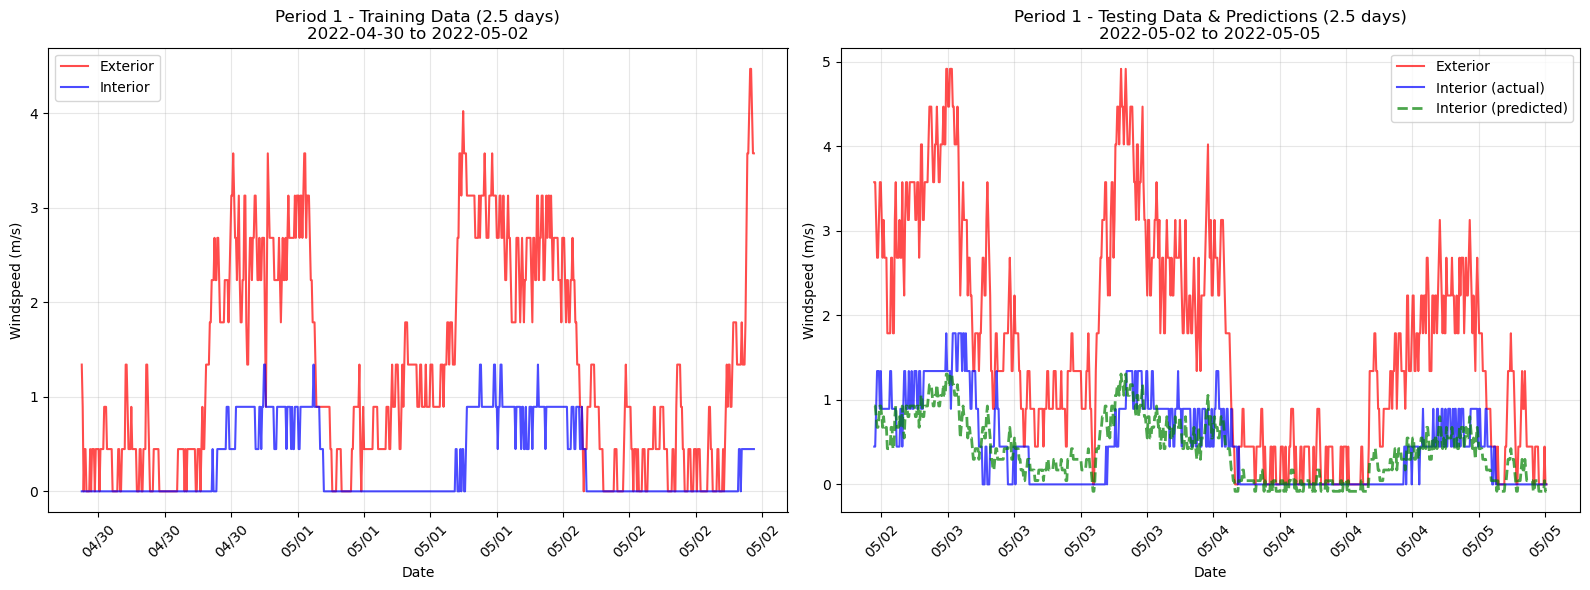

Period 2/10 - Train: 2021-11-19 04:15 to 2021-11-21 17:02 (60.8 hours)
  Test: 2021-11-21 17:07 to 2021-11-24 05:53 (60.8 hours)
  Train R²: 0.1469, Train RMSE: 0.1276 m/s
  Test RMSE: 0.1494 m/s, Test MAE: 0.0990 m/s



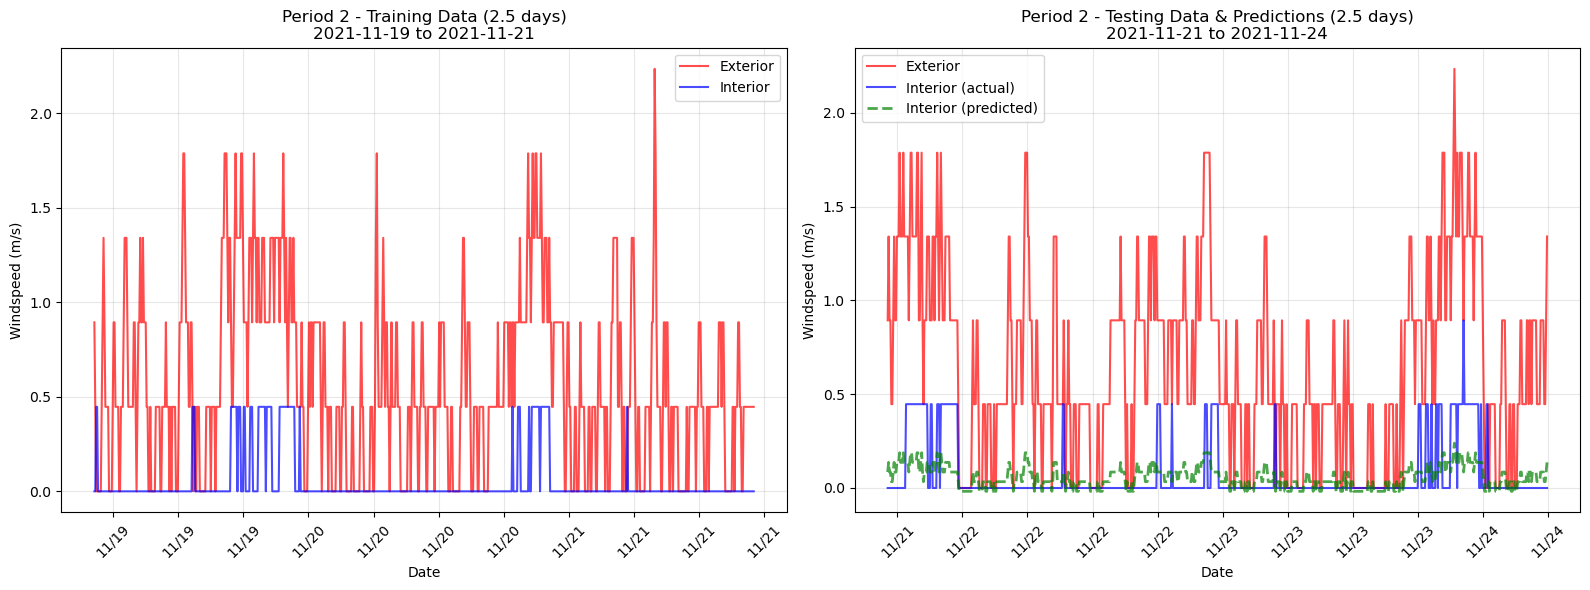

Period 3/10 - Train: 2022-03-19 05:04 to 2022-03-21 17:50 (60.8 hours)
  Test: 2022-03-21 17:55 to 2022-03-24 06:41 (60.8 hours)
  Train R²: 0.3305, Train RMSE: 0.3656 m/s
  Test RMSE: 0.2348 m/s, Test MAE: 0.1722 m/s



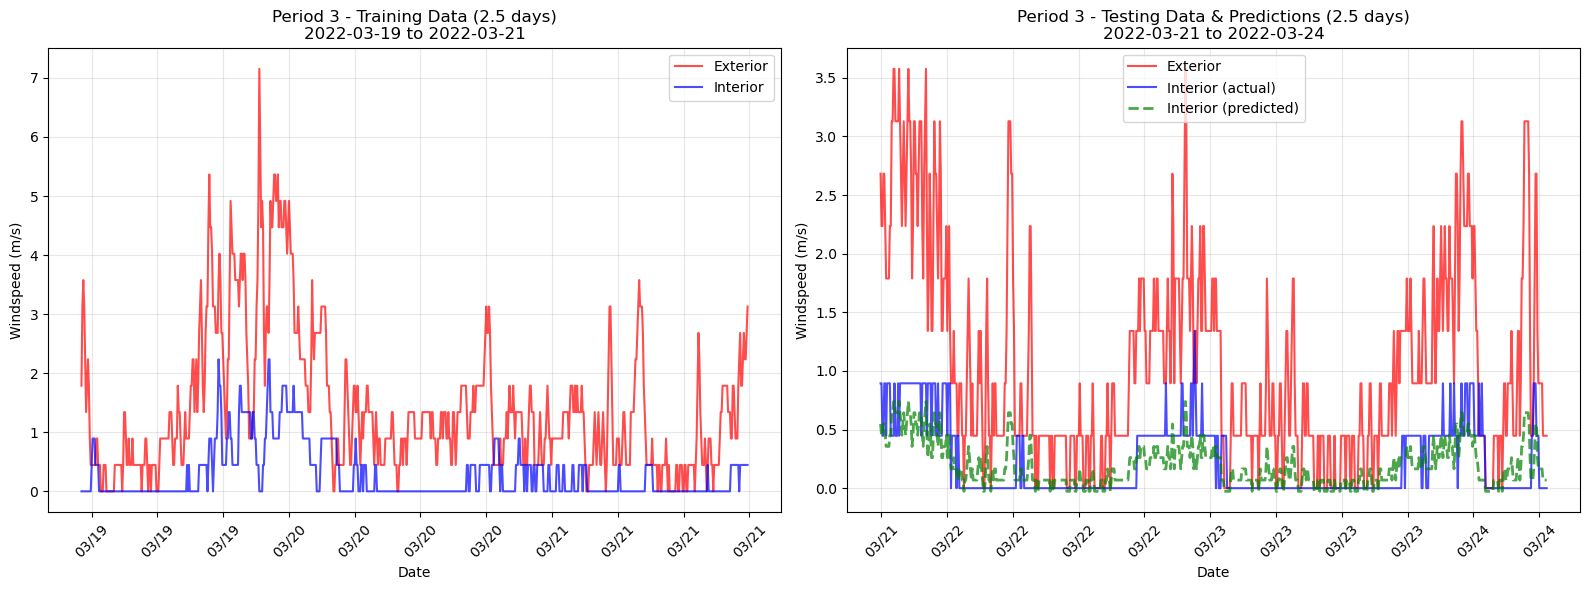

Period 4/10 - Train: 2022-06-15 23:40 to 2022-06-18 12:27 (60.8 hours)
  Test: 2022-06-18 12:32 to 2022-06-21 01:18 (60.8 hours)
  Train R²: 0.5113, Train RMSE: 0.3128 m/s
  Test RMSE: 0.3537 m/s, Test MAE: 0.2622 m/s



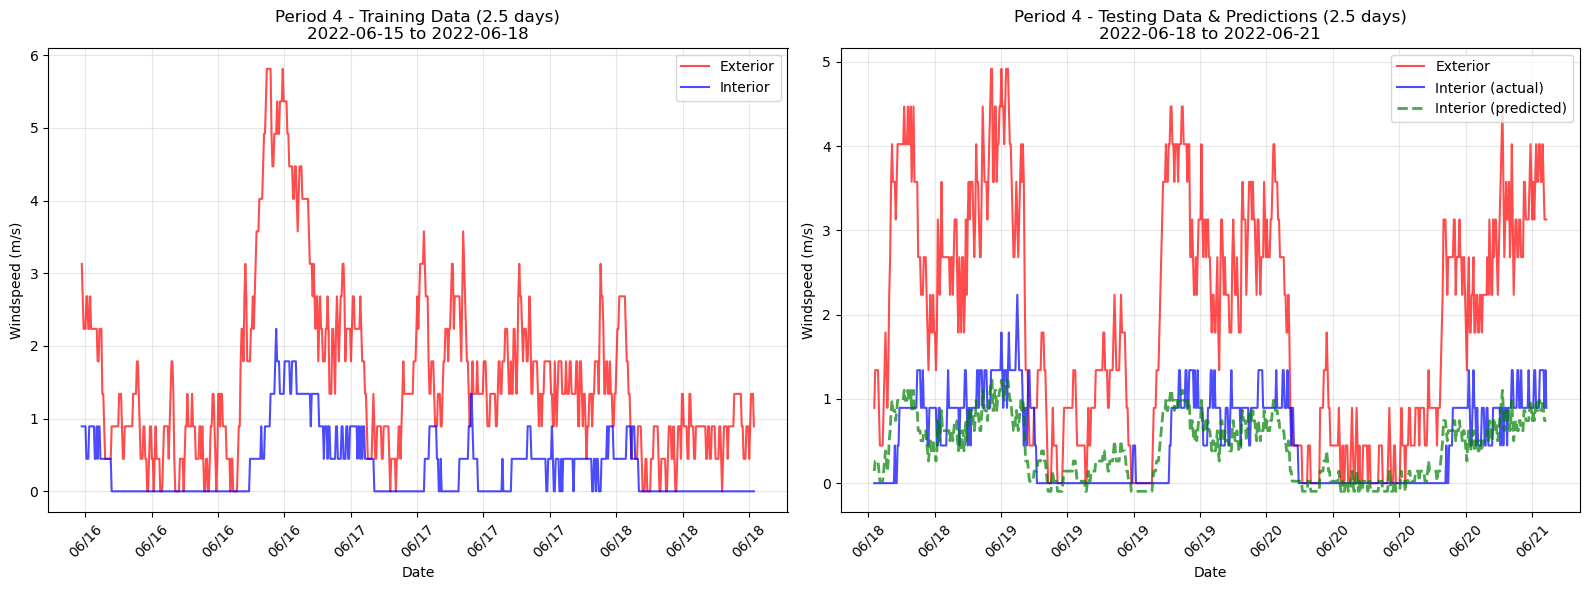

Period 5/10 - Train: 2022-04-10 21:54 to 2022-04-13 10:40 (60.8 hours)
  Test: 2022-04-13 10:45 to 2022-04-15 23:31 (60.8 hours)
  Train R²: 0.5938, Train RMSE: 0.3536 m/s
  Test RMSE: 0.3000 m/s, Test MAE: 0.2099 m/s



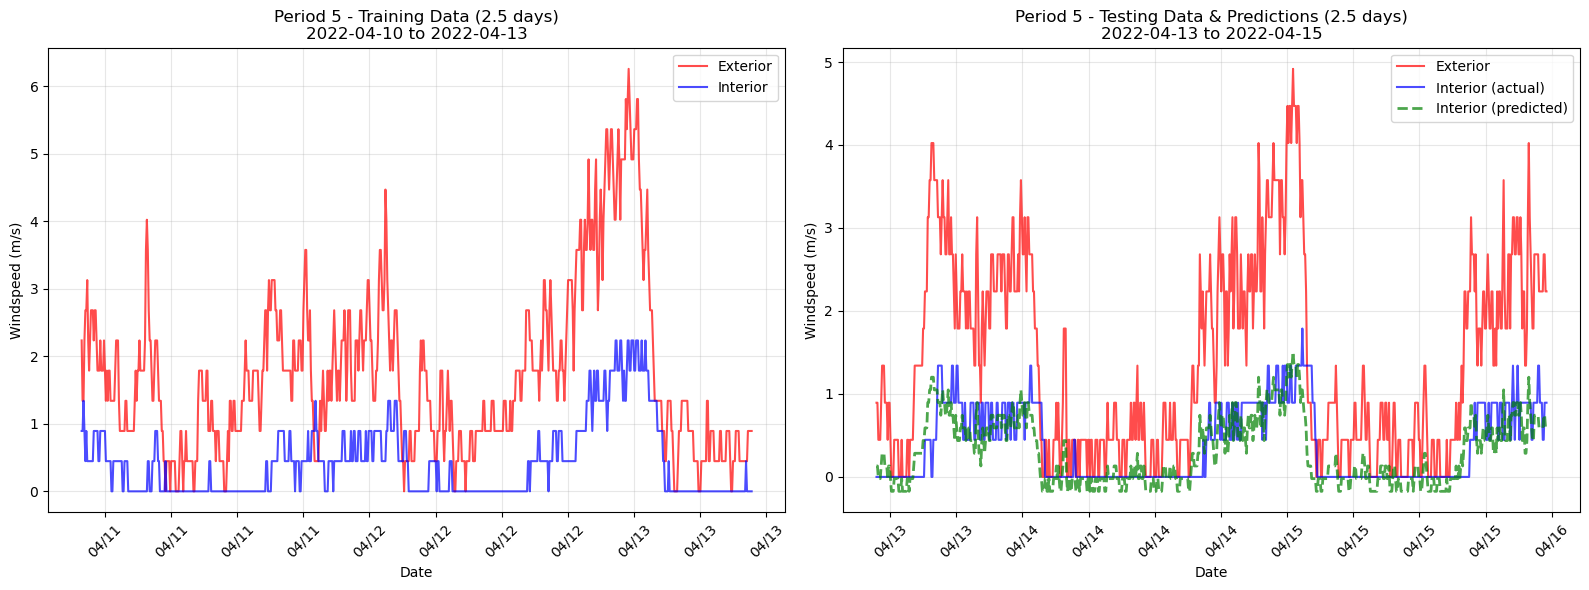

Period 6/10 - Train: 2022-05-10 09:41 to 2022-05-12 22:27 (60.8 hours)
  Test: 2022-05-12 22:32 to 2022-05-15 11:18 (60.8 hours)
  Train R²: 0.5244, Train RMSE: 0.3664 m/s
  Test RMSE: 0.2904 m/s, Test MAE: 0.2026 m/s



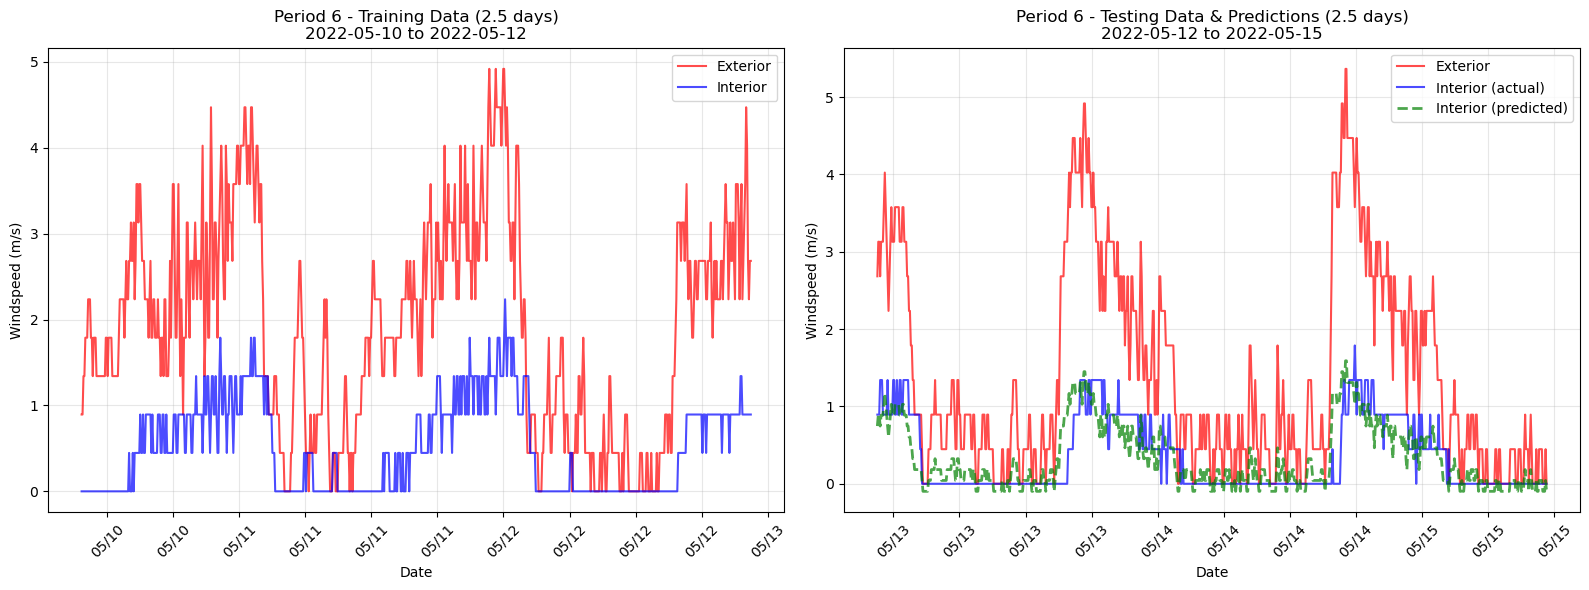

Period 7/10 - Train: 2022-02-13 11:20 to 2022-02-16 00:06 (60.8 hours)
  Test: 2022-02-16 00:12 to 2022-02-18 12:58 (60.8 hours)
  Train R²: 0.3647, Train RMSE: 0.3018 m/s
  Test RMSE: 0.2819 m/s, Test MAE: 0.2001 m/s



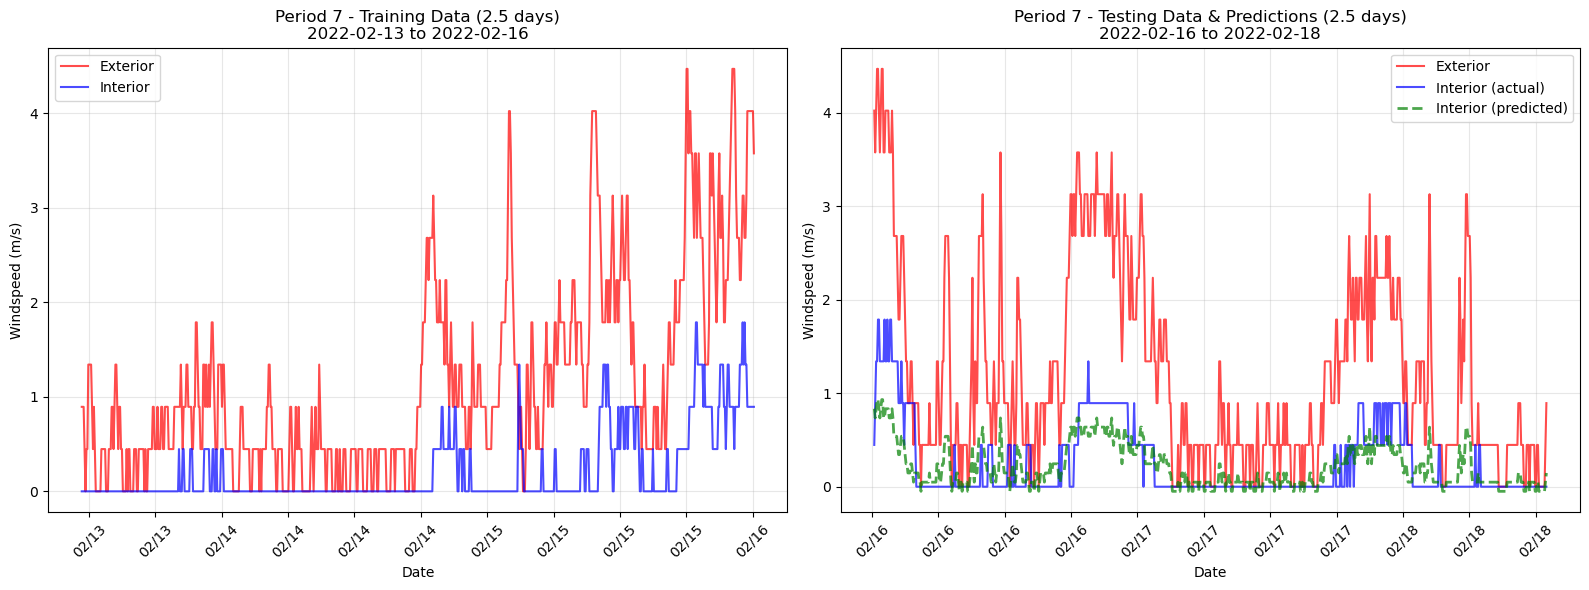

Period 8/10 - Train: 2022-05-05 17:16 to 2022-05-08 06:02 (60.8 hours)
  Test: 2022-05-08 06:07 to 2022-05-10 18:54 (60.8 hours)
  Train R²: 0.5568, Train RMSE: 0.3032 m/s
  Test RMSE: 0.4132 m/s, Test MAE: 0.3267 m/s



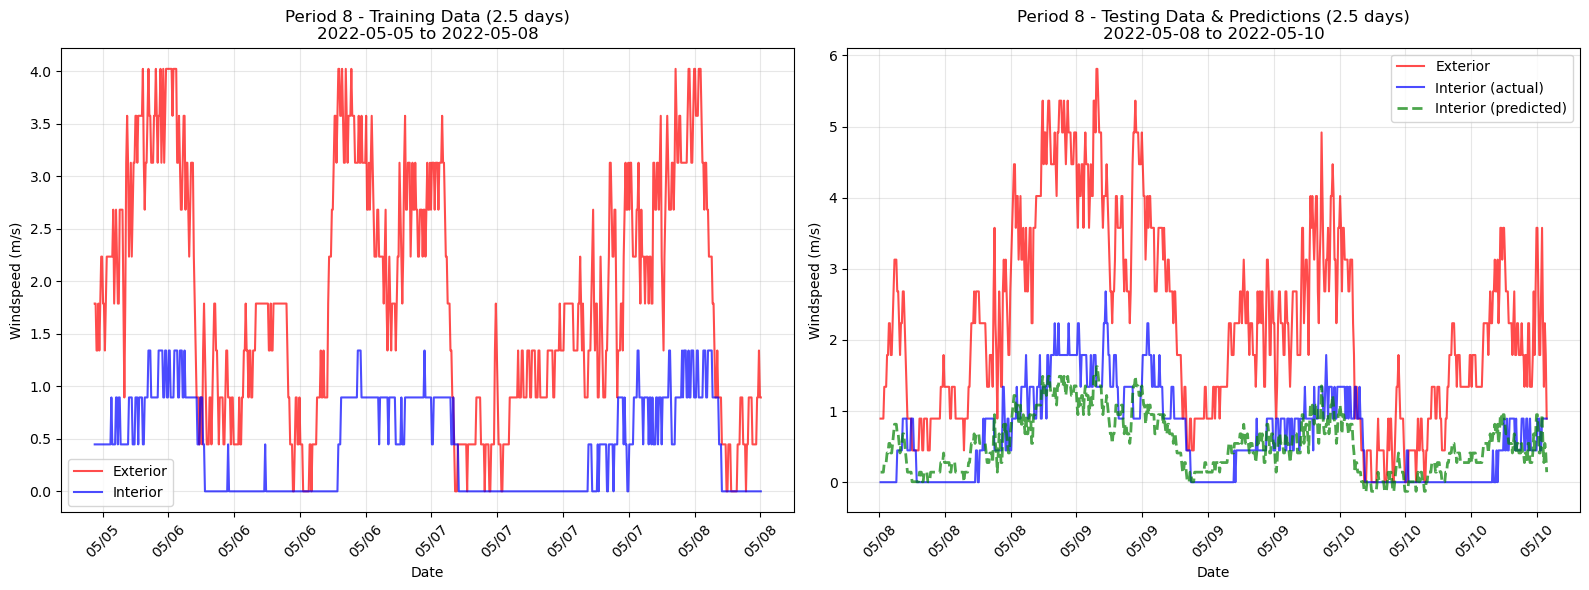

Period 9/10 - Train: 2021-12-07 19:48 to 2021-12-10 08:34 (60.8 hours)
  Test: 2021-12-10 08:39 to 2021-12-12 21:25 (60.8 hours)
  Train R²: 0.2174, Train RMSE: 0.1743 m/s
  Test RMSE: 0.1253 m/s, Test MAE: 0.0873 m/s



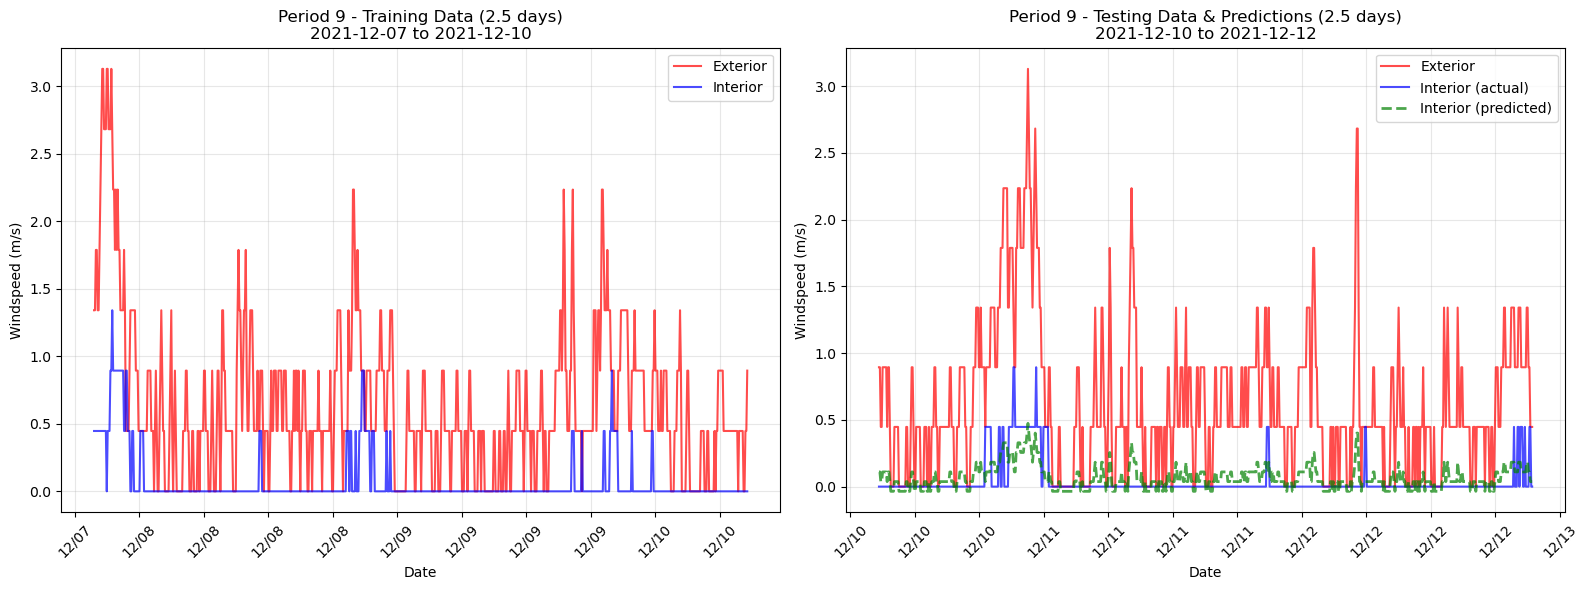

Period 10/10 - Train: 2021-09-09 03:54 to 2021-09-11 16:40 (60.8 hours)
  Test: 2021-09-11 16:45 to 2021-09-14 05:31 (60.8 hours)
  Train R²: 0.4210, Train RMSE: 0.3846 m/s
  Test RMSE: 0.3095 m/s, Test MAE: 0.2166 m/s



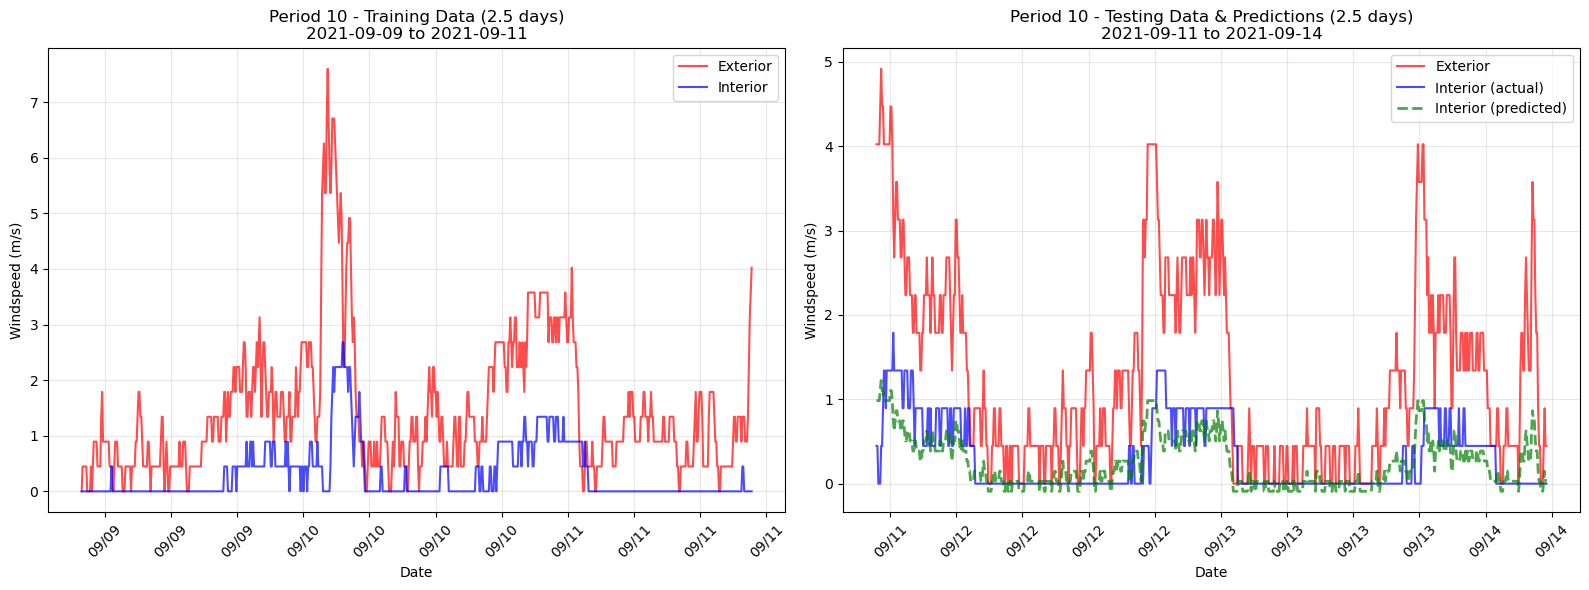


SUMMARY STATISTICS

Training Performance:
  Mean R²: 0.4276 ± 0.1599
  Mean RMSE: 0.2940 ± 0.0860 m/s

Testing Performance:
  Mean RMSE: 0.2779 ± 0.0877 m/s
  Mean MAE: 0.2018 ± 0.0712 m/s

DETAILED RESULTS
 period  train_start  train_end  test_start  test_end  train_samples  test_samples              train_start_date                train_end_date               test_start_date                 test_end_date  train_r2  train_rmse  test_rmse  test_mae  n_components
      1        89057      89777       89777     90497            720           720 2022-04-30 04:29:24.306951046 2022-05-02 17:15:40.615756035 2022-05-02 17:20:44.896548986 2022-05-05 06:07:08.034487009  0.609041    0.250034   0.320434  0.241176             1
      2        43135      43855       43855     44575            720           720 2021-11-19 04:15:54.588257074 2021-11-21 17:02:08.305593014 2021-11-21 17:07:12.590315104 2021-11-24 05:53:27.179054976  0.146903    0.127604   0.149400  0.098954             1
      3     

In [10]:
# Evaluate PCR on random periods with train_window=72, test_window=72
results_df = evaluate_pcr_on_random_periods(
    df, 
    n_periods=10, 
    train_window=72*10, 
    test_window=72*10, 
    n_components=12,
    random_seed=42,
    plot_periods=True,
    debug=True
)

Total data length: 174113
Max window size (total/2): 87056
Number of window sizes to test: 71
Window sizes: [72, 144, 216, 288, 360, 432, 504, 576, 648, 720]...[73080, 75960, 78840, 81720, 84600]

Evaluating PCR performance across different window sizes...

Testing window size: 72 samples (6.0 hours)

SUMMARY STATISTICS

Training Performance:
  Mean R²: 0.3848 ± 0.3905
  Mean RMSE: 0.1732 ± 0.1476 m/s

Testing Performance:
  Mean RMSE: 0.3387 ± 0.2596 m/s
  Mean MAE: 0.2771 ± 0.2324 m/s

Testing window size: 144 samples (12.0 hours)

SUMMARY STATISTICS

Training Performance:
  Mean R²: 0.3572 ± 0.2896
  Mean RMSE: 0.2192 ± 0.1205 m/s

Testing Performance:
  Mean RMSE: 0.3374 ± 0.2180 m/s
  Mean MAE: 0.2631 ± 0.1857 m/s

Testing window size: 216 samples (18.0 hours)

SUMMARY STATISTICS

Training Performance:
  Mean R²: 0.3890 ± 0.2468
  Mean RMSE: 0.2413 ± 0.1103 m/s

Testing Performance:
  Mean RMSE: 0.2690 ± 0.1098 m/s
  Mean MAE: 0.1957 ± 0.0865 m/s

Testing window size: 288 samples 

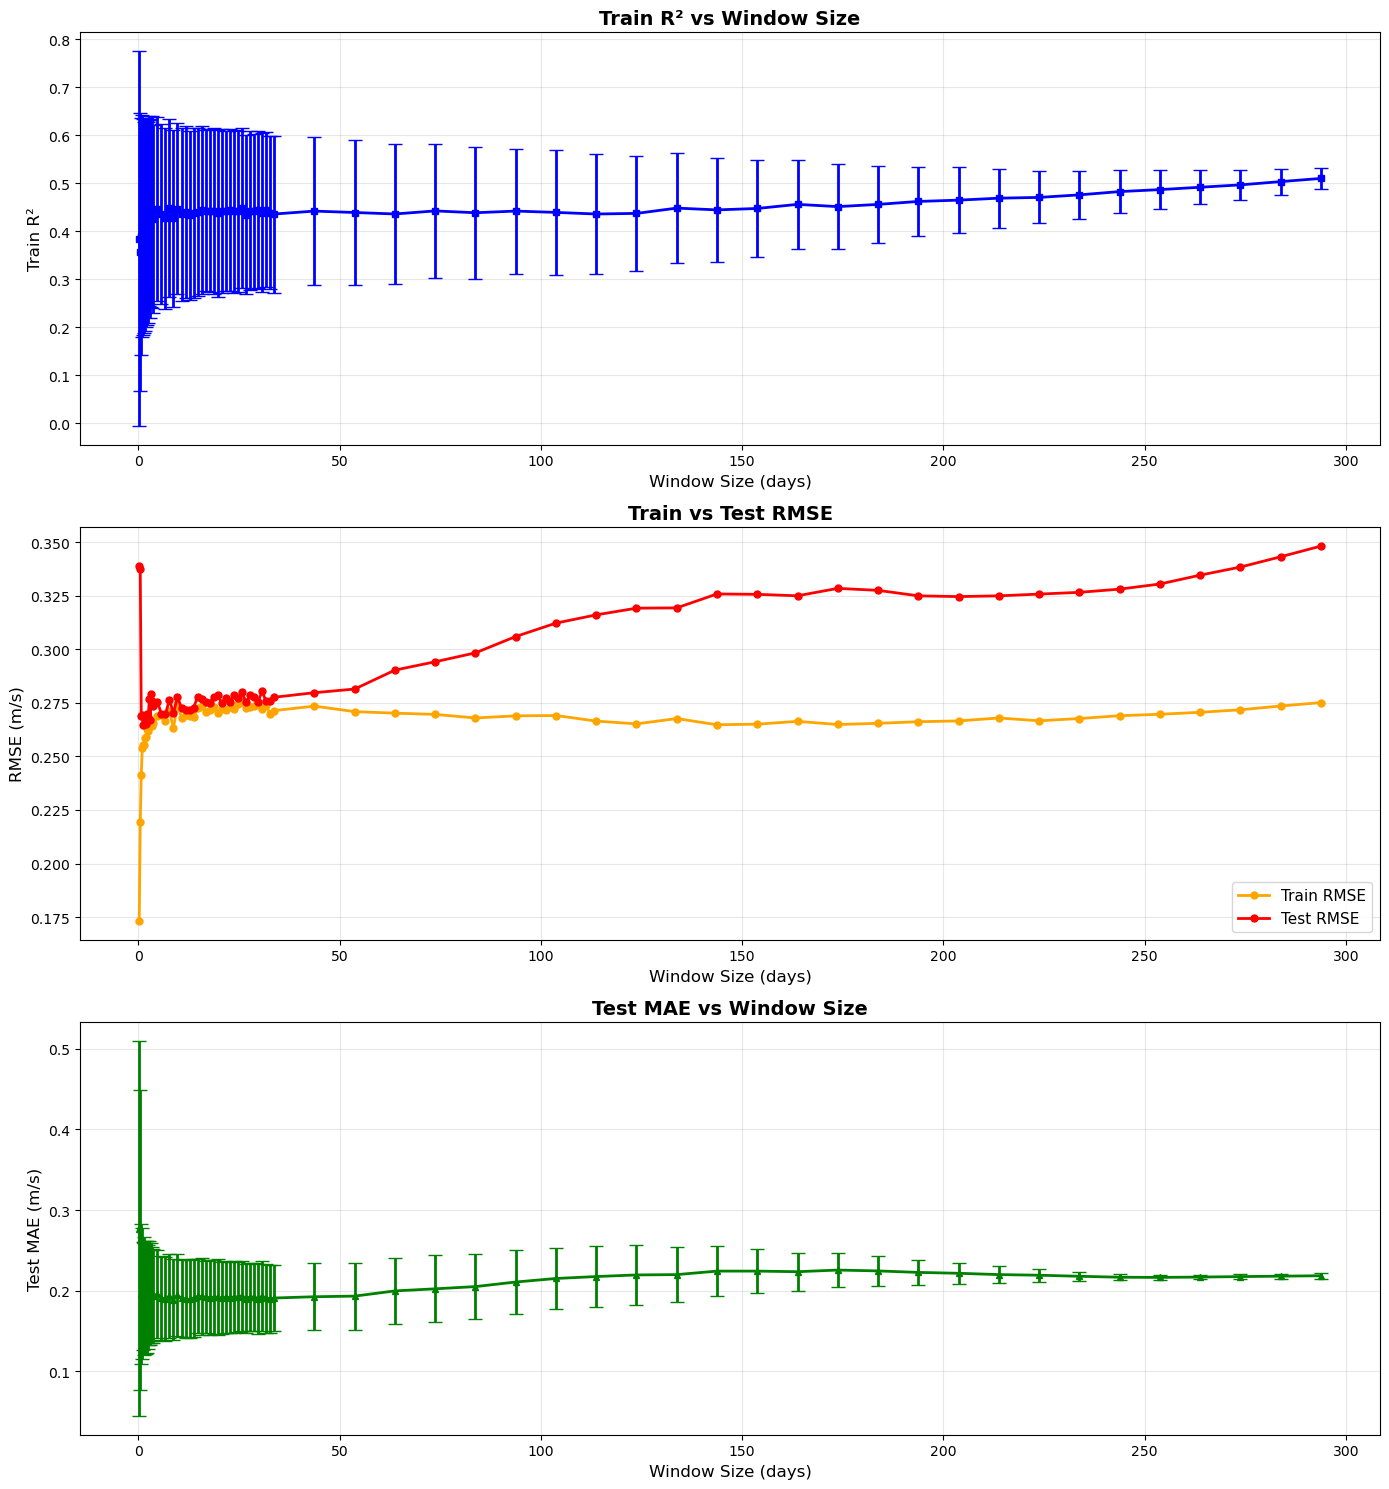


Analysis complete!


In [21]:
# Compare PCR performance across different window lengths
# Build error curves for different interval sizes

# Configuration
n_periods = 1000  # Number of random periods to test for each window size
n_components = 12

# Data sampling rate: 1 record every 5 minutes
MINUTES_PER_RECORD = 5

# Create window sizes with gradual increase in steps, stopping around total_length/2
total_length = len(df)
max_window = total_length // 2

# Build window_sizes progressively with less dense steps:
# - Phase 1: Step 72 (6 hours) for first ~15 windows (up to 1,080 samples)
#   Windows: 72, 144, 216, ... 1,080 samples
#   Time range: 6h, 12h, 18h, ... 90h
# - Phase 2: Step 288 (72×4 = 24 hours) until ~10,000 samples
#   Adds windows at 24-hour intervals
#   Covers the mid-range more efficiently
# - Phase 3: Step 2,880 (72×4×10 = 10 days) until max_window
#   Large jumps for the long-term windows
#   Reaches up to ~87,000 samples (total_length/2)

window_sizes = []

# Phase 1: step 72 (6 hours) for first ~15 windows
step1 = 72
for i in range(1, 16):
    w = step1 * i
    if w > max_window:
        break
    window_sizes.append(w)

# Phase 2: step 288 (72*4 = 24 hours) until ~10,000
step2 = 72 * 4
current = window_sizes[-1] if window_sizes else 0
while current + step2 <= min(10000, max_window):
    current += step2
    window_sizes.append(current)

# Phase 3: step 2,880 (72*4*10 = 10 days) until max_window
step3 = 72 * 4 * 10
while current + step3 <= max_window:
    current += step3
    window_sizes.append(current)

print(f"Total data length: {total_length}")
print(f"Max window size (total/2): {max_window}")
print(f"Number of window sizes to test: {len(window_sizes)}")
print(f"Window sizes: {window_sizes[:10]}...{window_sizes[-5:]}")

# Storage for aggregated results
window_comparison = []

print("\nEvaluating PCR performance across different window sizes...")

for window_size in window_sizes:
    # Convert samples to time (1 record every 5 minutes)
    window_hours = window_size * MINUTES_PER_RECORD / 60
    window_days = window_hours / 24
    
    # Create display label
    if window_days >= 1:
        window_label = f"{window_days:.1f} days ({window_hours:.1f} hours)"
    else:
        window_label = f"{window_hours:.1f} hours"
    
    print(f"\nTesting window size: {window_size} samples ({window_label})")
    
    # Evaluate PCR for this window size
    results_df = evaluate_pcr_on_random_periods(
        df, 
        n_periods=n_periods, 
        train_window=window_size, 
        test_window=window_size, 
        n_components=n_components,
        random_seed=42,
        plot_periods=False,
        debug=False
    )
    
    if results_df is not None and len(results_df) > 0:
        # Store aggregated metrics
        window_comparison.append({
            'window_size': window_size,
            'window_hours': window_hours,
            'window_days': window_days,
            'train_r2_mean': results_df['train_r2'].mean(),
            'train_r2_std': results_df['train_r2'].std(),
            'train_rmse_mean': results_df['train_rmse'].mean(),
            'train_rmse_std': results_df['train_rmse'].std(),
            'test_rmse_mean': results_df['test_rmse'].mean(),
            'test_rmse_std': results_df['test_rmse'].std(),
            'test_mae_mean': results_df['test_mae'].mean(),
            'test_mae_std': results_df['test_mae'].std(),
            'n_periods': len(results_df)
        })

# Create DataFrame with comparison results
comparison_df = pd.DataFrame(window_comparison)

print("\n" + "="*70)
print("WINDOW SIZE COMPARISON")
print("="*70)
print(comparison_df.to_string(index=False))

# Plot error curves
fig, axes = plt.subplots(3, 1, figsize=(14, 15))

# Determine if we should use days or hours for x-axis
use_days = comparison_df['window_days'].max() > 2
x_values = comparison_df['window_days'] if use_days else comparison_df['window_hours']
x_label = 'Window Size (days)' if use_days else 'Window Size (hours)'

# Plot 1: Train R² vs Window Size
ax = axes[0]
ax.errorbar(x_values, comparison_df['train_r2_mean'], 
            yerr=comparison_df['train_r2_std'], marker='s', capsize=5, 
            color='blue', linewidth=2, markersize=5)
ax.set_xlabel(x_label, fontsize=12)
ax.set_ylabel('Train R²', fontsize=12)
ax.set_title('Train R² vs Window Size', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Plot 2: Train vs Test RMSE Comparison
ax = axes[1]
ax.plot(x_values, comparison_df['train_rmse_mean'], 
        marker='o', color='orange', linewidth=2, markersize=5, label='Train RMSE')
ax.plot(x_values, comparison_df['test_rmse_mean'], 
        marker='o', color='red', linewidth=2, markersize=5, label='Test RMSE')
ax.set_xlabel(x_label, fontsize=12)
ax.set_ylabel('RMSE (m/s)', fontsize=12)
ax.set_title('Train vs Test RMSE', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Plot 3: Test MAE vs Window Size
ax = axes[2]
ax.errorbar(x_values, comparison_df['test_mae_mean'], 
            yerr=comparison_df['test_mae_std'], marker='^', capsize=5, 
            color='green', linewidth=2, markersize=5)
ax.set_xlabel(x_label, fontsize=12)
ax.set_ylabel('Test MAE (m/s)', fontsize=12)
ax.set_title('Test MAE vs Window Size', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nAnalysis complete!")


Showing detailed view of first 29.8 days
Number of window sizes in this range: 41


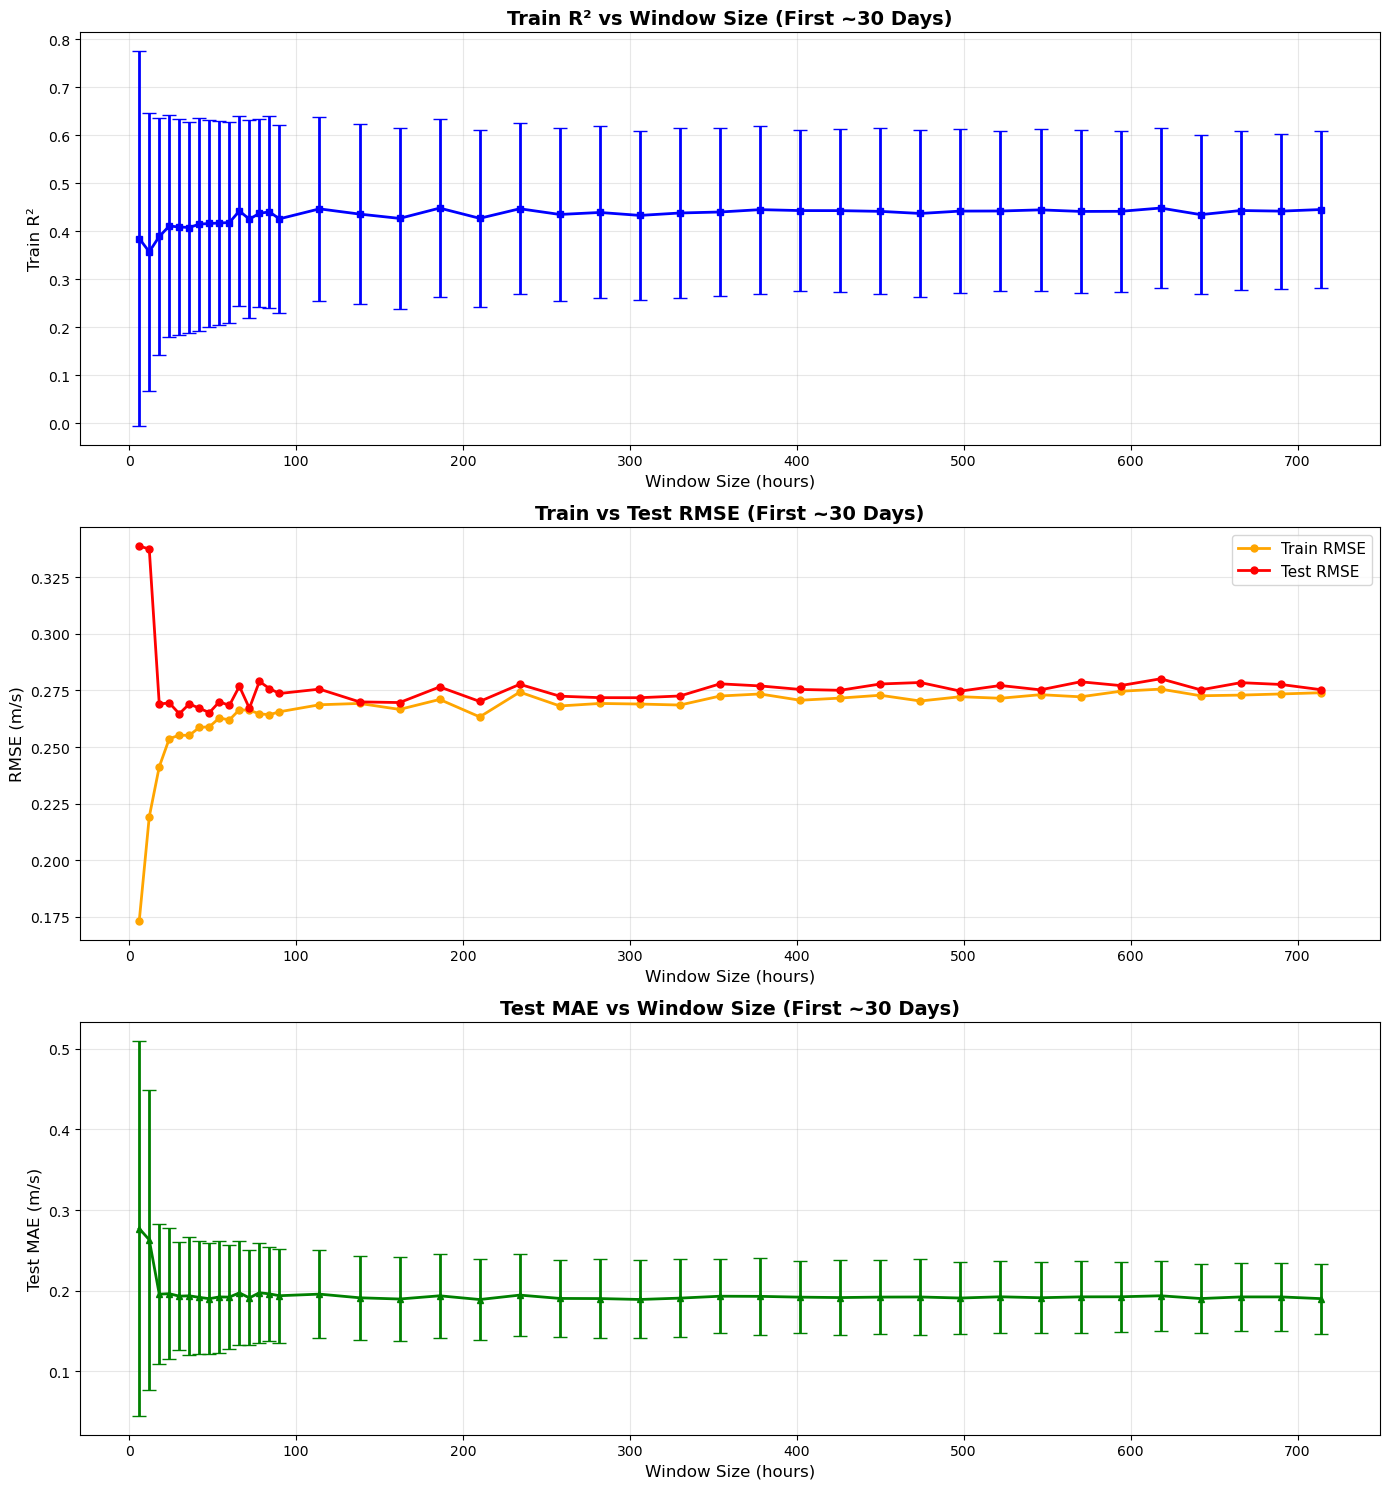


Short-term analysis complete!


In [23]:
# Zoom in on first ~30 days of window sizes for detailed view
comparison_short = comparison_df[comparison_df['window_days'] <= 30].copy()

print(f"\nShowing detailed view of first {comparison_short['window_days'].max():.1f} days")
print(f"Number of window sizes in this range: {len(comparison_short)}")

# Plot error curves for short-term windows
fig, axes = plt.subplots(3, 1, figsize=(14, 15))

# Use hours for x-axis since we're looking at shorter windows
x_values_short = comparison_short['window_hours']
x_label_short = 'Window Size (hours)'

# Plot 1: Train R² vs Window Size (Short-term)
ax = axes[0]
ax.errorbar(x_values_short, comparison_short['train_r2_mean'], 
            yerr=comparison_short['train_r2_std'], marker='s', capsize=5, 
            color='blue', linewidth=2, markersize=5)
ax.set_xlabel(x_label_short, fontsize=12)
ax.set_ylabel('Train R²', fontsize=12)
ax.set_title('Train R² vs Window Size (First ~30 Days)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Plot 2: Train vs Test RMSE Comparison (Short-term)
ax = axes[1]
ax.plot(x_values_short, comparison_short['train_rmse_mean'], 
        marker='o', color='orange', linewidth=2, markersize=5, label='Train RMSE')
ax.plot(x_values_short, comparison_short['test_rmse_mean'], 
        marker='o', color='red', linewidth=2, markersize=5, label='Test RMSE')
ax.set_xlabel(x_label_short, fontsize=12)
ax.set_ylabel('RMSE (m/s)', fontsize=12)
ax.set_title('Train vs Test RMSE (First ~30 Days)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Plot 3: Test MAE vs Window Size (Short-term)
ax = axes[2]
ax.errorbar(x_values_short, comparison_short['test_mae_mean'], 
            yerr=comparison_short['test_mae_std'], marker='^', capsize=5, 
            color='green', linewidth=2, markersize=5)
ax.set_xlabel(x_label_short, fontsize=12)
ax.set_ylabel('Test MAE (m/s)', fontsize=12)
ax.set_title('Test MAE vs Window Size (First ~30 Days)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nShort-term analysis complete!")